## Connect Google Colab to Google Drive


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## SECTION 3.1- IMPORT REGRESSION AND MACHINE-LEARNING LIBRARIES


In [ ]:

import os
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    RidgeCV,
    Lasso,
    LassoCV
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

print("Regression libraries imported successfully.")

Regression libraries imported successfully.


## SECTION 3.2- LOADTHE PREPARED LA DATASET


In [ ]:

PREPARED_LA_PATH = (
    "/content/drive/MyDrive/MSC Dissertation/"
    "Final Main 3/Prepared Data/Prepared_LA_Data.xlsx"
)

if "la_analysis" not in globals():

    if not os.path.exists(PREPARED_LA_PATH):

        raise FileNotFoundError(
            "The prepared LA dataset could not be found."
            "Run Section 1 or update PREPARED_LA_PATH."
        )

    la_analysis = pd.read_excel(
        PREPARED_LA_PATH
    )

    print("Prepared LA dataset loaded from Google Drive.")

else:

    print("Existing la_analysis dataframe will be used.")

print(
    f"LA dataset dimensions: "
    f"{la_analysis.shape[0]} rows and "
    f"{la_analysis.shape[1]} columns."
)

display(la_analysis.head())

Existing la_analysis dataframe will be used.
LA dataset dimensions: 294 rows and 30 columns.


,LA Authority,LA to LEA Mapped,Urbanity,Total no of pupils,Total no of Schools,Average SEN Rate,Average EHC Rate,Average Total SEND Rate,Average IMD Score,Average Income Score Rate,Average Employment Score,"Average Education, Skills and Training Score",Average Income Deprivation Affecting Children Index (IDACI) Score (rate),Total Population,Total Dependent child Population (0-15),Total working age Population (18-66),No of special schools,geo-Political Zone,new_la_code,district_administrative_code,LAD24NM,LAD24CD,geometry,Child Population Percentage,"Schools per 10,000 Pupils","Special Schools per 10,000 Pupils",Pupils as Percentage of Population,Urbanity Category,Broad Urban-Rural Group,IMD Quintile
0,Adur,West Sussex,1,9099,21,0.1738,0.1415,0.3153,14.9620,0.1833,0.1151,22.6790,0.2753,64725,11704,37632,2,South East,E10000032,E07000223,Adur,E07000223,"MULTIPOLYGON (((-0.279155 50.829507, -0.280235...",18.0827,23.0795,2.1980,14.0579,Mostly Urban,Urban,Q2
1,Amber Valley,Derbyshire,1,18726,73,0.1491,0.1004,0.2495,18.7127,0.1919,0.1314,21.9658,0.3013,126934,21150,77288,5,East Midlands,E10000007,E07000032,Amber Valley,E07000032,"POLYGON ((-1.495366 53.133965, -1.493616 53.13...",16.6622,38.9832,2.6701,14.7525,Mostly Urban,Urban,Q3
2,Arun,West Sussex,1,18895,46,0.1442,0.1105,0.2547,19.3290,0.1900,0.1179,25.4335,0.3292,166381,25398,94293,2,South East,E10000032,E07000224,Arun,E07000224,"MULTIPOLYGON (((-0.749958 50.756688, -0.750031...",15.2650,24.3451,1.0585,11.3565,Mostly Urban,Urban,Q3
3,Ashfield,Nottinghamshire,1,19899,49,0.1211,0.0960,0.2171,25.8176,0.2617,0.1749,30.6790,0.4113,127101,23467,78109,4,East Midlands,E10000024,E07000170,Ashfield,E07000170,"POLYGON ((-1.284152 53.168382, -1.281992 53.16...",18.4633,24.6244,2.0102,15.6561,Mostly Urban,Urban,Q4
4,Ashford,Kent,2,23207,62,0.1273,0.1621,0.2895,19.8691,0.2037,0.1202,22.2792,0.3054,135741,26712,81863,8,South East,E10000016,E07000105,Ashford,E07000105,"POLYGON ((0.955032 51.270246, 0.958151 51.2685...",19.6787,26.7161,3.4472,17.0965,Moderately Urban,Urban,Q3


In [ ]:


PREPARED_LA_PATH = (
    "/content/drive/MyDrive/MSC Dissertation/"
    "Final Main 3/Prepared Data/Prepared_LA_Data.xlsx"
)

if "la_analysis" not in globals():

    if not os.path.exists(PREPARED_LA_PATH):

        raise FileNotFoundError(
            "The prepared LA dataset could not be found."
            "Run Section 1 or update PREPARED_LA_PATH."
        )

    la_analysis = pd.read_excel(
        PREPARED_LA_PATH
    )

    print("Prepared LA dataset loaded from Google Drive.")

else:

    print("Existing la_analysis dataframe will be used.")

print(
    f"LA dataset dimensions: "
    f"{la_analysis.shape[0]} rows and "
    f"{la_analysis.shape[1]} columns."
)

display(la_analysis.head())

Existing la_analysis dataframe will be used.
LA dataset dimensions: 294 rows and 30 columns.


,LA Authority,LA to LEA Mapped,Urbanity,Total no of pupils,Total no of Schools,Average SEN Rate,Average EHC Rate,Average Total SEND Rate,Average IMD Score,Average Income Score Rate,Average Employment Score,"Average Education, Skills and Training Score",Average Income Deprivation Affecting Children Index (IDACI) Score (rate),Total Population,Total Dependent child Population (0-15),Total working age Population (18-66),No of special schools,geo-Political Zone,new_la_code,district_administrative_code,LAD24NM,LAD24CD,geometry,Child Population Percentage,"Schools per 10,000 Pupils","Special Schools per 10,000 Pupils",Pupils as Percentage of Population,Urbanity Category,Broad Urban-Rural Group,IMD Quintile
0,Adur,West Sussex,1,9099,21,0.1738,0.1415,0.3153,14.9620,0.1833,0.1151,22.6790,0.2753,64725,11704,37632,2,South East,E10000032,E07000223,Adur,E07000223,"MULTIPOLYGON (((-0.279155 50.829507, -0.280235...",18.0827,23.0795,2.1980,14.0579,Mostly Urban,Urban,Q2
1,Amber Valley,Derbyshire,1,18726,73,0.1491,0.1004,0.2495,18.7127,0.1919,0.1314,21.9658,0.3013,126934,21150,77288,5,East Midlands,E10000007,E07000032,Amber Valley,E07000032,"POLYGON ((-1.495366 53.133965, -1.493616 53.13...",16.6622,38.9832,2.6701,14.7525,Mostly Urban,Urban,Q3
2,Arun,West Sussex,1,18895,46,0.1442,0.1105,0.2547,19.3290,0.1900,0.1179,25.4335,0.3292,166381,25398,94293,2,South East,E10000032,E07000224,Arun,E07000224,"MULTIPOLYGON (((-0.749958 50.756688, -0.750031...",15.2650,24.3451,1.0585,11.3565,Mostly Urban,Urban,Q3
3,Ashfield,Nottinghamshire,1,19899,49,0.1211,0.0960,0.2171,25.8176,0.2617,0.1749,30.6790,0.4113,127101,23467,78109,4,East Midlands,E10000024,E07000170,Ashfield,E07000170,"POLYGON ((-1.284152 53.168382, -1.281992 53.16...",18.4633,24.6244,2.0102,15.6561,Mostly Urban,Urban,Q4
4,Ashford,Kent,2,23207,62,0.1273,0.1621,0.2895,19.8691,0.2037,0.1202,22.2792,0.3054,135741,26712,81863,8,South East,E10000016,E07000105,Ashford,E07000105,"POLYGON ((0.955032 51.270246, 0.958151 51.2685...",19.6787,26.7161,3.4472,17.0965,Moderately Urban,Urban,Q3


## SECTION 3.3- DEFINE THE REGRESSION OUTCOME VARIABLES


In [ ]:

#Model SEN Support, EHC plans and Total SEND separately.

#The three outcomes are not placed in the same model because they
#represent related but distinct aspects of SEND provision.

#SEN and EHC rates are not used as predictors of Total SEND because:
#-Total SEND Rate = SEN Rate + EHC Rate
#-Using them as predictors would create direct mathematical leakage.

LA_REGRESSION_OUTCOMES = [
    "Average SEN Rate",
    "Average EHC Rate",
    "Average Total SEND Rate"
]

for outcome in LA_REGRESSION_OUTCOMES:
    print("-", outcome)

- Average SEN Rate
- Average EHC Rate
- Average Total SEND Rate


## SECTION 3.4- DEFINE CORE AND EXTENDED PREDICTOR GROUPS


In [ ]:

#Construct staged regression models.

#Model A is a smaller and easier-to-interpret model.
#Model B adds wider socioeconomic, demographic and school-provision characteristics.


#Comparing the two models shows whether the additional contextual
#variables meaningfully improve explanatory performance.


CORE_NUMERIC_PREDICTORS = [
    "Average IMD Score"
]

CORE_CATEGORICAL_PREDICTORS = [
    "Urbanity Category",
    "geo-Political Zone"
]

EXTENDED_NUMERIC_PREDICTORS = [
    "Average IMD Score",
    "Average Income Score Rate",
    "Average Employment Score",
    "Average Education, Skills and Training Score",
    (
        "Average Income Deprivation Affecting Children "
        "Index (IDACI) Score (rate)"
    ),
    "Child Population Percentage",
    "Schools per 10,000 Pupils",
    "Special Schools per 10,000 Pupils",
    "Pupils as Percentage of Population"
]

EXTENDED_CATEGORICAL_PREDICTORS = [
    "Urbanity Category",
    "geo-Political Zone"
]

print("Core numerical predictors:")
for variable in CORE_NUMERIC_PREDICTORS:
    print("-", variable)

print("\nCore categorical predictors:")
for variable in CORE_CATEGORICAL_PREDICTORS:
    print("-", variable)

print("\nExtended numerical predictors:")
for variable in EXTENDED_NUMERIC_PREDICTORS:
    print("-", variable)

Core numerical predictors:
- Average IMD Score

Core categorical predictors:
- Urbanity Category
- geo-Political Zone

Extended numerical predictors:
- Average IMD Score
- Average Income Score Rate
- Average Employment Score
- Average Education, Skills and Training Score
- Average Income Deprivation Affecting Children Index (IDACI) Score (rate)
- Child Population Percentage
- Schools per 10,000 Pupils
- Special Schools per 10,000 Pupils
- Pupils as Percentage of Population


## SECTION 3.5- VALIDATE ALL REGRESSION VARIABLES


In [ ]:

#Confirm that every outcome and predictor required by the models
#exists in the prepared dataset.

#The analysis stops if an expected variable is missing rather thanproducing an incomplete or misleading model.


required_regression_columns = list(
    dict.fromkeys(
        LA_REGRESSION_OUTCOMES
        + EXTENDED_NUMERIC_PREDICTORS
        + EXTENDED_CATEGORICAL_PREDICTORS
    )
)

missing_regression_columns = [
    column
    for column in required_regression_columns
    if column not in la_analysis.columns
]

if missing_regression_columns:

    raise KeyError(
        "The following regression variables are missing: "
        f"{missing_regression_columns}"
    )

print("All regression variables are available.")

All regression variables are available.


## FIX- STANDARDISE URBANITY CATEGORY LABELS


In [ ]:

#Correct inconsistent category spelling before regression so that all 294 Local Authorities remain eligible for analysis.

la_regression = la_analysis.copy()

la_regression["Urbanity Category"] = (
    la_regression["Urbanity Category"]
    .replace({
        "Mostly Urban": "Most Urban",
        "Mosty Rural": "Most Rural"
    })
)

URBANITY_ORDER = [
    "Most Urban",
    "Moderately Urban",
    "Moderately Rural",
    "Most Rural"
]

la_regression["Urbanity Category"] = pd.Categorical(
    la_regression["Urbanity Category"],
    categories=URBANITY_ORDER,
    ordered=False
)

print(
    la_regression["Urbanity Category"]
    .value_counts(dropna=False)
)

print(
    "\nUsable authorities:",
    la_regression["Urbanity Category"].notna().sum()
)

Urbanity Category
Most Urban          178
Moderately Urban     45
Moderately Rural     38
Most Rural           33
Name: count, dtype: int64

Usable authorities: 294


## SECTION 3.6- PREPARE CATEGORICAL REGRESSION VARIABLES


In [ ]:

#Convert the Urbanity and region variables into ordered categorical
#data with clearly defined reference categories.

#Reference Urbanity category:
#Most Urban


#Each other Urbanity coefficient in OLS will therefore show the difference from the Most Urban group, after controlling for the
#other variables in the model.


#The reference region will be the first category listed below.







URBANITY_ORDER = [
    "Most Urban",
    "Moderately Urban",
    "Moderately Rural",
    "Most Rural"
]

REGION_ORDER = sorted(
    la_analysis["geo-Political Zone"]
    .dropna()
    .unique()
    .tolist()
)



la_regression["Urbanity Category"] = pd.Categorical(
    la_regression["Urbanity Category"],
    categories=URBANITY_ORDER,
    ordered=False
)

la_regression["geo-Political Zone"] = pd.Categorical(
    la_regression["geo-Political Zone"],
    categories=REGION_ORDER,
    ordered=False
)

print("Urbanity categories:")
print(la_regression["Urbanity Category"].cat.categories.tolist())

print("\nRegional categories:")
print(la_regression["geo-Political Zone"].cat.categories.tolist())

print("\nReference Urbanity category: Most Urban")
print("Reference region:", REGION_ORDER[0])

Urbanity categories:
['Most Urban', 'Moderately Urban', 'Moderately Rural', 'Most Rural']

Regional categories:
['East Midlands', 'East of England', 'London', 'North East', 'North West', 'South East', 'South West', 'West Midlands', 'Yorkshire and The Humber']

Reference Urbanity category: Most Urban
Reference region: East Midlands


In [ ]:

#Convert the Urbanity and region variables into ordered categorical
#data with clearly defined reference categories.

#Reference Urbanity category:
#Most Urban


#Each other Urbanity coefficient in OLS will therefore show the
#difference from the Most Urban group, after controlling for the
#other variables in the model.


#The reference region will be the first category listed below.







URBANITY_ORDER = [
    "Most Urban",
    "Moderately Urban",
    "Moderately Rural",
    "Most Rural"
]

REGION_ORDER = sorted(
    la_analysis["geo-Political Zone"]
    .dropna()
    .unique()
    .tolist()
)



la_regression["Urbanity Category"] = pd.Categorical(
    la_regression["Urbanity Category"],
    categories=URBANITY_ORDER,
    ordered=False
)

la_regression["geo-Political Zone"] = pd.Categorical(
    la_regression["geo-Political Zone"],
    categories=REGION_ORDER,
    ordered=False
)

print("Urbanity categories:")
print(la_regression["Urbanity Category"].cat.categories.tolist())

print("\nRegional categories:")
print(la_regression["geo-Political Zone"].cat.categories.tolist())

print("\nReference Urbanity category: Most Urban")
print("Reference region:", REGION_ORDER[0])

Urbanity categories:
['Most Urban', 'Moderately Urban', 'Moderately Rural', 'Most Rural']

Regional categories:
['East Midlands', 'East of England', 'London', 'North East', 'North West', 'South East', 'South West', 'West Midlands', 'Yorkshire and The Humber']

Reference Urbanity category: Most Urban
Reference region: East Midlands


In [ ]:

#Convert the Urbanity and region variables into ordered categorical
#data with clearly defined reference categories.

#Reference Urbanity category:
#Most Urban


#Each other Urbanity coefficient in OLS will therefore show the
#difference from the Most Urban group, after controlling for the
#other variables in the model.


#The reference region will be the first category listed below.







URBANITY_ORDER = [
    "Most Urban",
    "Moderately Urban",
    "Moderately Rural",
    "Most Rural"
]

REGION_ORDER = sorted(
    la_analysis["geo-Political Zone"]
    .dropna()
    .unique()
    .tolist()
)



la_regression["Urbanity Category"] = pd.Categorical(
    la_regression["Urbanity Category"],
    categories=URBANITY_ORDER,
    ordered=False
)

la_regression["geo-Political Zone"] = pd.Categorical(
    la_regression["geo-Political Zone"],
    categories=REGION_ORDER,
    ordered=False
)

print("Urbanity categories:")
print(la_regression["Urbanity Category"].cat.categories.tolist())

print("\nRegional categories:")
print(la_regression["geo-Political Zone"].cat.categories.tolist())

print("\nReference Urbanity category: Most Urban")
print("Reference region:", REGION_ORDER[0])

Urbanity categories:
['Most Urban', 'Moderately Urban', 'Moderately Rural', 'Most Rural']

Regional categories:
['East Midlands', 'East of England', 'London', 'North East', 'North West', 'South East', 'South West', 'West Midlands', 'Yorkshire and The Humber']

Reference Urbanity category: Most Urban
Reference region: East Midlands


## SECTION 3.7- CHECK THE REGRESSION SAMPLE


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:

#Confirm whether missing values exist among the model outcomes and
#predictors.

#The final dataset is expected to be complete.Any missing values identified here should be investigated before modelling.


regression_missing_report = (
    la_regression[
        required_regression_columns
    ]
    .isna()
    .sum()
    .rename("Missing Values")
    .to_frame()
)

display(regression_missing_report)

print(
    "Total missing regression values:",
    regression_missing_report["Missing Values"].sum()
)

,Missing Values
Average SEN Rate,0
Average EHC Rate,0
Average Total SEND Rate,0
Average IMD Score,0
Average Income Score Rate,0
Average Employment Score,0
"Average Education, Skills and Training Score",0
Average Income Deprivation Affecting Children Index (IDACI) Score (rate),0
Child Population Percentage,0
"Schools per 10,000 Pupils",0


Total missing regression values: 0


## SECTION 3.7- CHECK THE REGRESSION SAMPLE


In [ ]:

#Confirm whether missing values exist among the model outcomes and
#predictors.


#The final dataset is expected to be complete.Any missing values
#identified here should be investigated before modelling.


regression_missing_report = (
    la_regression[
        required_regression_columns
    ]
    .isna()
    .sum()
    .rename("Missing Values")
    .to_frame()
)

display(regression_missing_report)

print(
    "Total missing regression values:",
    regression_missing_report["Missing Values"].sum()
)

,Missing Values
Average SEN Rate,0
Average EHC Rate,0
Average Total SEND Rate,0
Average IMD Score,0
Average Income Score Rate,0
Average Employment Score,0
"Average Education, Skills and Training Score",0
Average Income Deprivation Affecting Children Index (IDACI) Score (rate),0
Child Population Percentage,0
"Schools per 10,000 Pupils",0


Total missing regression values: 0


## SECTION 3.9- CREATE SAFE VARIABLE NAMES FOR STATSMODELS OLS


In [ ]:

#Rename model variables in a separate dataframe so that OLS
#formulas remain readable and avoid errors caused by spaces,
#brackets, hyphens or punctuation.


OLS_RENAME_MAP = {
    "Average SEN Rate": "sen_rate",
    "Average EHC Rate": "ehc_rate",
    "Average Total SEND Rate": "total_send_rate",

    "Average IMD Score": "imd_score",
    "Average Income Score Rate": "income_score",
    "Average Employment Score": "employment_score",

    "Average Education, Skills and Training Score":
        "education_score",

    (
        "Average Income Deprivation Affecting Children "
        "Index (IDACI) Score (rate)"
    ): "idaci_score",

    "Child Population Percentage": "child_population_pct",
    "Schools per 10,000 Pupils": "schools_per_10000",
    "Special Schools per 10,000 Pupils":
        "special_schools_per_10000",

    "Pupils as Percentage of Population":
        "pupils_population_pct",

    "Urbanity Category": "urbanity_category",
    "geo-Political Zone": "region"
}

ols_data = la_regression.rename(
    columns=OLS_RENAME_MAP
).copy()

print("Statsmodels variable names created successfully.")

display(
    ols_data[
        list(OLS_RENAME_MAP.values())
    ].head()
)

Statsmodels variable names created successfully.


,sen_rate,ehc_rate,total_send_rate,imd_score,income_score,employment_score,education_score,idaci_score,child_population_pct,schools_per_10000,special_schools_per_10000,pupils_population_pct,urbanity_category,region
0,0.1738,0.1415,0.3153,14.9620,0.1833,0.1151,22.6790,0.2753,18.0827,23.0795,2.1980,14.0579,Most Urban,South East
1,0.1491,0.1004,0.2495,18.7127,0.1919,0.1314,21.9658,0.3013,16.6622,38.9832,2.6701,14.7525,Most Urban,East Midlands
2,0.1442,0.1105,0.2547,19.3290,0.1900,0.1179,25.4335,0.3292,15.2650,24.3451,1.0585,11.3565,Most Urban,South East
3,0.1211,0.0960,0.2171,25.8176,0.2617,0.1749,30.6790,0.4113,18.4633,24.6244,2.0102,15.6561,Most Urban,East Midlands
4,0.1273,0.1621,0.2895,19.8691,0.2037,0.1202,22.2792,0.3054,19.6787,26.7161,3.4472,17.0965,Moderately Urban,South East


## SECTION 3.10- DEFINE THE CORE AND EXTENDED OLS FORMULAS


In [ ]:

#Create staged explanatory models for each SEND outcome.
#
#C(urbanity_category, Treatment(reference="Most Urban"))
#treats Most Urban as the baseline.
#
#Urbanity coefficients answer whether each other Urbanity group
#differs from the Most Urban group after controlling for the
#remaining predictors.
#
#C(region) adds regional fixed effects and controls for broad
#regional differences.


OUTCOME_SAFE_NAMES = {
    "Average SEN Rate": "sen_rate",
    "Average EHC Rate": "ehc_rate",
    "Average Total SEND Rate": "total_send_rate"
}

CORE_OLS_PREDICTOR_FORMULA = """
imd_score
+ C(urbanity_category, Treatment(reference="Most Urban"))
+ C(region)
"""

EXTENDED_OLS_PREDICTOR_FORMULA = """
imd_score
+ income_score
+ employment_score
+ education_score
+ idaci_score
+ child_population_pct
+ schools_per_10000
+ special_schools_per_10000
+ pupils_population_pct
+ C(urbanity_category, Treatment(reference="Most Urban"))
+ C(region)
"""

CORE_OLS_FORMULAS = {
    original_outcome:
    f"{safe_outcome} ~ {CORE_OLS_PREDICTOR_FORMULA}"

    for original_outcome, safe_outcome
    in OUTCOME_SAFE_NAMES.items()
}

EXTENDED_OLS_FORMULAS = {
    original_outcome:
    f"{safe_outcome} ~ {EXTENDED_OLS_PREDICTOR_FORMULA}"

    for original_outcome, safe_outcome
    in OUTCOME_SAFE_NAMES.items()
}

print("Core OLS formulas created.")
print("Extended OLS formulas created.")

Core OLS formulas created.
Extended OLS formulas created.


## SECTION 3.11- FIT THE CORE OLS MODELS


In [ ]:

#Estimate the association between SEND outcomes and:
#deprivation;
#Urbanity;
#English region.

#These models provide a clear baseline before additional contextual
#predictors are introduced.

#HC3 robust standard errors are used because they reduce the effect
#of heteroscedasticity on confidence intervals and p-values.


core_ols_models = {}

for outcome, formula in CORE_OLS_FORMULAS.items():

    model = smf.ols(
        formula=formula,
        data=ols_data
    ).fit(
        cov_type="HC3"
    )

    core_ols_models[outcome] = model

    print("=" * 85)
    print(f"CORE OLS MODEL: {outcome}")
    print("=" * 85)

    print(model.summary())

CORE OLS MODEL: Average SEN Rate
                            OLS Regression Results                            
Dep. Variable:               sen_rate   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     5.662
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           1.01e-08
Time:                        10:46:04   Log-Likelihood:                 775.50
No. Observations:                 294   AIC:                            -1525.
Df Residuals:                     281   BIC:                            -1477.
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------

## SECTION 3.12- FIT THE EXTENDED OLS MODELS


In [ ]:

#Add detailed deprivation, demographic and school-provision
#variables to the core models.
#
#Comparing core and extended models shows whether the wider local
#characteristics improve explanation power.

#These models may experience multicollinearity because several deprivation measures describe overlapping socioeconomic factors.


extended_ols_models = {}

for outcome, formula in EXTENDED_OLS_FORMULAS.items():

    model = smf.ols(
        formula=formula,
        data=ols_data
    ).fit(
        cov_type="HC3"
    )

    extended_ols_models[outcome] = model

    print("=" * 85)
    print(f"EXTENDED OLS MODEL: {outcome}")
    print("=" * 85)

    print(model.summary())

EXTENDED OLS MODEL: Average SEN Rate
                            OLS Regression Results                            
Dep. Variable:               sen_rate   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                     8.969
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           1.93e-20
Time:                        10:46:04   Log-Likelihood:                 812.93
No. Observations:                 294   AIC:                            -1584.
Df Residuals:                     273   BIC:                            -1507.
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------

## SECTION 3.13- COMPARE CORE AND EXTENDED OLS MODELS


In [ ]:

#Compare model explanatory performance using:
#R-squared;
#adjusted R-squared;
#AIC;
#BIC;
#number of predictors.


#Adjusted R-squared is especially important because it penalises
#the addition of predictors that do not meaningfully improve the
#model.


ols_comparison_rows = []

for outcome in LA_REGRESSION_OUTCOMES:

    core_model = core_ols_models[outcome]
    extended_model = extended_ols_models[outcome]

    for model_name, model in [
        ("Core OLS", core_model),
        ("Extended OLS", extended_model)
    ]:

        ols_comparison_rows.append({
            "Outcome": outcome,
            "Model": model_name,
            "Observations": int(model.nobs),
            "R-squared": model.rsquared,
            "Adjusted R-squared": model.rsquared_adj,
            "AIC": model.aic,
            "BIC": model.bic,
            "Number of Estimated Parameters":
                int(model.df_model + 1)
        })

ols_model_comparison_table = pd.DataFrame(
    ols_comparison_rows
)

display(
    ols_model_comparison_table.round(4)
)

,Outcome,Model,Observations,R-squared,Adjusted R-squared,AIC,BIC,Number of Estimated Parameters
0,Average SEN Rate,Core OLS,294,0.1865,0.1518,-1524.9967,-1477.1101,13
1,Average SEN Rate,Extended OLS,294,0.3694,0.3232,-1583.8562,-1506.5011,21
2,Average EHC Rate,Core OLS,294,0.1123,0.0744,-1149.0423,-1101.1558,13
3,Average EHC Rate,Extended OLS,294,0.6959,0.6737,-1448.0535,-1370.6983,21
4,Average Total SEND Rate,Core OLS,294,0.1727,0.1374,-1104.6299,-1056.7434,13
5,Average Total SEND Rate,Extended OLS,294,0.5834,0.5529,-1290.3124,-1212.9572,21


## SECTION 3.14- EXTRACT OLS COEFFICIENTS AND CONFIDENCE INTERVALS


In [ ]:

#Convert OLS output into structured tables containing:
#coefficient estimates;
#robust standard errors;
#test statistics;
#p-values;
#95% confidence intervals.


def extract_ols_coefficients(
    fitted_model,
    outcome_name,
    model_name
):
    """
    Extract coefficient results from a fitted statsmodels model.
    """

    confidence_intervals = (
        fitted_model.conf_int()
    )

    coefficient_table = pd.DataFrame({
        "Term": fitted_model.params.index,
        "Coefficient": fitted_model.params.values,
        "Robust Standard Error":
            fitted_model.bse.values,
        "Test Statistic":
            fitted_model.tvalues.values,
        "p-value":
            fitted_model.pvalues.values,
        "95% CI Lower":
            confidence_intervals[0].values,
        "95% CI Upper":
            confidence_intervals[1].values
    })

    coefficient_table.insert(
        0,
        "Outcome",
        outcome_name
    )

    coefficient_table.insert(
        1,
        "Model",
        model_name
    )

    coefficient_table[
        "Statistically Significant"
    ] = (
        coefficient_table["p-value"] < 0.05
    )

    return coefficient_table


core_ols_coefficient_tables = {}
extended_ols_coefficient_tables = {}

for outcome in LA_REGRESSION_OUTCOMES:

    core_ols_coefficient_tables[outcome] = (
        extract_ols_coefficients(
            fitted_model=core_ols_models[outcome],
            outcome_name=outcome,
            model_name="Core OLS"
        )
    )

    extended_ols_coefficient_tables[outcome] = (
        extract_ols_coefficients(
            fitted_model=extended_ols_models[outcome],
            outcome_name=outcome,
            model_name="Extended OLS"
        )
    )

print("OLS coefficient tables created.")

OLS coefficient tables created.


## SECTION 3.15- EXTRACT AND INTERPRET URBANITY COEFFICIENTS


In [ ]:

#Directly assess whether Urbanity categories differ from the
#reference category after controlling for other predictors.

#Reference category:
#Most Urban

#A positive coefficient means the category has a higher predicted
#SEND rate than Most Urban authorities, holding other predictors
#constant.

#A negative coefficient means the category has a lower predicted
#SEND rate than Most Urban authorities, holding other predictors
#constant.

#A p-value below 0.05 indicates that the adjusted difference is
#statistically significant.

#Important:
#A non-significant coefficient does not prove that the categories
#are identical.It means the model does not find strong enough
#evidence of an adjusted difference in this sample.


def extract_urbanity_coefficients(
    coefficient_table
):
    """
    Extract Urbanity dummy coefficients from an OLS table.
    """

    urbanity_rows = coefficient_table[
        coefficient_table["Term"]
        .str.contains(
            "urbanity_category",
            case=False,
            regex=False
        )
    ].copy()

    urbanity_rows[
        "Coefficient Percentage Points"
    ] = (
        urbanity_rows["Coefficient"] * 100
    )

    urbanity_rows[
        "95% CI Lower Percentage Points"
    ] = (
        urbanity_rows["95% CI Lower"] * 100
    )

    urbanity_rows[
        "95% CI Upper Percentage Points"
    ] = (
        urbanity_rows["95% CI Upper"] * 100
    )

    return urbanity_rows


urbanity_coefficient_tables = {}

for outcome in LA_REGRESSION_OUTCOMES:

    urbanity_table = extract_urbanity_coefficients(
        extended_ols_coefficient_tables[outcome]
    )

    urbanity_coefficient_tables[outcome] = (
        urbanity_table
    )

    print("=" * 85)
    print(
        f"ADJUSTED URBANITY EFFECTS: {outcome}"
    )
    print(
        "Reference category: Most Urban"
    )
    print("=" * 85)

    display(
        urbanity_table[
            [
                "Term",
                "Coefficient Percentage Points",
                "95% CI Lower Percentage Points",
                "95% CI Upper Percentage Points",
                "p-value",
                "Statistically Significant"
            ]
        ].round(4)
    )

ADJUSTED URBANITY EFFECTS: Average SEN Rate
Reference category: Most Urban


,Term,Coefficient Percentage Points,95% CI Lower Percentage Points,95% CI Upper Percentage Points,p-value,Statistically Significant
1,"C(urbanity_category, Treatment(reference=""Most...",-0.7705,-1.4035,-0.1375,0.0171,True
2,"C(urbanity_category, Treatment(reference=""Most...",-0.7533,-1.5643,0.0577,0.0687,False
3,"C(urbanity_category, Treatment(reference=""Most...",-0.7380,-1.4758,-0.0001,0.0500,True


ADJUSTED URBANITY EFFECTS: Average EHC Rate
Reference category: Most Urban


,Term,Coefficient Percentage Points,95% CI Lower Percentage Points,95% CI Upper Percentage Points,p-value,Statistically Significant
1,"C(urbanity_category, Treatment(reference=""Most...",0.1756,-0.6264,0.9775,0.6678,False
2,"C(urbanity_category, Treatment(reference=""Most...",-0.3748,-1.5110,0.7613,0.5179,False
3,"C(urbanity_category, Treatment(reference=""Most...",-0.5154,-1.4740,0.4431,0.2919,False


ADJUSTED URBANITY EFFECTS: Average Total SEND Rate
Reference category: Most Urban


,Term,Coefficient Percentage Points,95% CI Lower Percentage Points,95% CI Upper Percentage Points,p-value,Statistically Significant
1,"C(urbanity_category, Treatment(reference=""Most...",-0.5949,-1.6655,0.4757,0.2761,False
2,"C(urbanity_category, Treatment(reference=""Most...",-1.1281,-2.7344,0.4781,0.1686,False
3,"C(urbanity_category, Treatment(reference=""Most...",-1.2534,-2.4354,-0.0714,0.0377,True


## SECTION 3.16- GENERATE URBANITY INTERPRETATION STATEMENTS


In [ ]:

#Translate the Urbanity coefficients into clear statements.
#
#The statements distinguish:
#coefficient direction;
#size in percentage points;
#statistical significance;
#the Most Urban reference group.


def interpret_urbanity_coefficient_row(
    row,
    reference_group="Most Urban"
):
    """
    Produce a concise interpretation of one Urbanity coefficient.
    """

    term = row["Term"]

    category = (
        term.split("[T.")[-1]
        .replace("]", "")
    )

    coefficient_pp = (
        row["Coefficient Percentage Points"]
    )

    p_value = row["p-value"]

    if coefficient_pp > 0:
        direction_text = "higher"
    elif coefficient_pp < 0:
        direction_text = "lower"
    else:
        direction_text = "equal"

    if p_value < 0.05:
        significance_text = (
            "This adjusted difference was statistically significant"
        )
    else:
        significance_text = (
            "This adjusted difference was not statistically significant"
        )

    return (
        f"{category} authorities had a predicted rate "
        f"{abs(coefficient_pp):.2f} percentage points "
        f"{direction_text} than {reference_group} authorities, "
        f"holding the other model predictors constant."
        f"{significance_text} (p = {p_value:.3f})."
    )


for outcome, table in (
    urbanity_coefficient_tables.items()
):

    print("=" * 85)
    print(
        f"URBANITY INTERPRETATION: {outcome}"
    )
    print("=" * 85)

    for _, row in table.iterrows():

        print(
            interpret_urbanity_coefficient_row(
                row
            )
        )

URBANITY INTERPRETATION: Average SEN Rate
Moderately Urban authorities had a predicted rate 0.77 percentage points lower than Most Urban authorities, holding the other model predictors constant. This adjusted difference was statistically significant (p = 0.017).
Moderately Rural authorities had a predicted rate 0.75 percentage points lower than Most Urban authorities, holding the other model predictors constant. This adjusted difference was not statistically significant (p = 0.069).
Most Rural authorities had a predicted rate 0.74 percentage points lower than Most Urban authorities, holding the other model predictors constant. This adjusted difference was statistically significant (p = 0.050).
URBANITY INTERPRETATION: Average EHC Rate
Moderately Urban authorities had a predicted rate 0.18 percentage points higher than Most Urban authorities, holding the other model predictors constant. This adjusted difference was not statistically significant (p = 0.668).
Moderately Rural authorities 

## SECTION 3.17- JOINT WALD TEST OF URBANITY COEFFICIENTS


In [ ]:

#Test whether the Urbanity variable as a whole contributes to each
#OLS model.
#
#Null hypothesis:
#All Urbanity coefficients are simultaneously equal to zero.
#
#A p-value below 0.05 suggests that at least one Urbanity category
#differs significantly from the Most Urban reference category,
#after controlling for the other predictors.


def run_urbanity_joint_test(
    fitted_model
):
    """
    Conduct a joint Wald test of all Urbanity coefficients.
    """

    urbanity_terms = [
        term
        for term in fitted_model.params.index
        if "urbanity_category" in term
    ]

    if len(urbanity_terms) == 0:

        return {
            "Number of Urbanity Coefficients": 0,
            "Wald Statistic": np.nan,
            "p-value": np.nan,
            "Interpretation":
                "No Urbanity coefficients found"
        }

    restrictions = ", ".join(
        f"{term} = 0"
        for term in urbanity_terms
    )

    test_result = fitted_model.wald_test(
        restrictions,
        scalar=True
    )

    p_value = float(
        np.asarray(test_result.pvalue)
    )

    statistic = float(
        np.asarray(test_result.statistic)
    )

    interpretation = (
        "Urbanity is jointly statistically significant"
        if p_value < 0.05
        else "Urbanity is not jointly statistically significant"
    )

    return {
        "Number of Urbanity Coefficients":
            len(urbanity_terms),
        "Wald Statistic":
            statistic,
        "p-value":
            p_value,
        "Interpretation":
            interpretation
    }


urbanity_joint_test_rows = []

for outcome, fitted_model in (
    extended_ols_models.items()
):

    result = run_urbanity_joint_test(
        fitted_model
    )

    result["Outcome"] = outcome

    urbanity_joint_test_rows.append(
        result
    )

urbanity_joint_test_table = pd.DataFrame(
    urbanity_joint_test_rows
)

display(
    urbanity_joint_test_table[
        [
            "Outcome",
            "Number of Urbanity Coefficients",
            "Wald Statistic",
            "p-value",
            "Interpretation"
        ]
    ].round(4)
)

,Outcome,Number of Urbanity Coefficients,Wald Statistic,p-value,Interpretation
0,Average SEN Rate,3,7.1523,0.0672,Urbanity is not jointly statistically significant
1,Average EHC Rate,3,2.8013,0.4233,Urbanity is not jointly statistically significant
2,Average Total SEND Rate,3,4.3350,0.2275,Urbanity is not jointly statistically significant


## SECTION 3.18- CREATE TRAINING AND TESTING DATASETS


In [ ]:

#Divide the Local Authorities into:
#80% training data;
#20% test data.

#The training sample is used to fit the models.
#The test sample evaluates performance on authorities not used
#during fitting.

#A fixed random state makes the results reproducible.


ML_NUMERIC_PREDICTORS = EXTENDED_NUMERIC_PREDICTORS.copy()

ML_CATEGORICAL_PREDICTORS = (
    EXTENDED_CATEGORICAL_PREDICTORS.copy()
)

ML_PREDICTORS = (
    ML_NUMERIC_PREDICTORS
    + ML_CATEGORICAL_PREDICTORS
)

X_full = la_regression[
    ML_PREDICTORS
].copy()

train_test_splits = {}

for outcome in LA_REGRESSION_OUTCOMES:

    y_full = la_regression[
        outcome
    ].copy()

    (
        X_train,
        X_test,
        y_train,
        y_test
    ) = train_test_split(
        X_full,
        y_full,
        test_size=0.20,
        random_state=42
    )

    train_test_splits[outcome] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print(
        f"{outcome}: "
        f"{len(X_train)} training observations and "
        f"{len(X_test)} test observations."
    )

Average SEN Rate: 235 training observations and 59 test observations.
Average EHC Rate: 235 training observations and 59 test observations.
Average Total SEND Rate: 235 training observations and 59 test observations.


## SECTION 3.19- BUILD REGRESSION PREPROCESSING PIPELINES


In [ ]:



#Numerical pipeline:
#median imputation as protection against unexpected missing values;
#StandardScaler for linear, Ridge and Lasso models.

#Categorical pipeline:
#most-frequent imputation;
#one-hot encoding;
#drop the first category to provide reference categories.


#Random Forest receives encoded predictors but does not require
#numerical scaling.


linear_numeric_pipeline = Pipeline(
    steps=[
        (
            "numeric_imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

tree_numeric_pipeline = Pipeline(
    steps=[
        (
            "numeric_imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "categorical_imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "one_hot_encoder",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            linear_numeric_pipeline,
            ML_NUMERIC_PREDICTORS
        ),
        (
            "categorical",
            categorical_pipeline,
            ML_CATEGORICAL_PREDICTORS
        )
    ],
    remainder="drop"
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_pipeline,
            ML_NUMERIC_PREDICTORS
        ),
        (
            "categorical",
            categorical_pipeline,
            ML_CATEGORICAL_PREDICTORS
        )
    ],
    remainder="drop"
)

print("Regression preprocessing pipelines created.")

Regression preprocessing pipelines created.


## SECTION 3.20- DEFINE THE REGRESSION MODELS


In [ ]:

#Compare four models:

#1.Linear Regression
#Provides a machine-learning baseline equivalent to an
#unregularised linear relationship.

#2.Ridge Regression
#Reduces unstable coefficients when predictors are correlated.

#3.Lasso Regression
#Can reduce weak predictor coefficients to zero.

#4.Random Forest Regression
#Captures non-linear relationships and predictor interactions.


regression_model_templates = {
    "Linear Regression": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(linear_preprocessor)
            ),
            (
                "model",
                LinearRegression()
            )
        ]
    ),

    "Ridge Regression": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(linear_preprocessor)
            ),
            (
                "model",
                Ridge()
            )
        ]
    ),

    "Lasso Regression": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(linear_preprocessor)
            ),
            (
                "model",
                Lasso(
                    max_iter=20000
                )
            )
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(tree_preprocessor)
            ),
            (
                "model",
                RandomForestRegressor(
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )
}

print("Regression models defined:")
for model_name in regression_model_templates:
    print("-", model_name)

Regression models defined:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest


## SECTION 3.21- DEFINE FIVE-FOLD CROSS-VALIDATION


In [ ]:

#Evaluate model stability across five different training and
#validation splits.

#Cross-validation reduces reliance on one particular train-test
#division and provides a more stable estimate of performance.


cross_validation_strategy = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

CROSS_VALIDATION_SCORING = {
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error"
}

print("Five-fold cross-validation configured.")

Five-fold cross-validation configured.


## SECTION 3.22- TUNE RIDGE REGRESSION


In [ ]:

#Select the Ridge regularisation strength, alpha.

#A larger alpha produces stronger coefficient shrinkage.

#GridSearchCV selects the alpha that gives the strongest average
#cross-validation R-squared on the training dataset.


RIDGE_PARAMETER_GRID = {
    "model__alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ]
}

best_ridge_models = {}
ridge_tuning_results = []

for outcome in LA_REGRESSION_OUTCOMES:

    split = train_test_splits[outcome]

    ridge_grid_search = GridSearchCV(
        estimator=clone(
            regression_model_templates[
                "Ridge Regression"
            ]
        ),
        param_grid=RIDGE_PARAMETER_GRID,
        scoring="r2",
        cv=cross_validation_strategy,
        n_jobs=-1
    )

    ridge_grid_search.fit(
        split["X_train"],
        split["y_train"]
    )

    best_ridge_models[outcome] = (
        ridge_grid_search.best_estimator_
    )

    ridge_tuning_results.append({
        "Outcome": outcome,
        "Best Alpha":
            ridge_grid_search.best_params_[
                "model__alpha"
            ],
        "Best Mean CV R-squared":
            ridge_grid_search.best_score_
    })

ridge_tuning_table = pd.DataFrame(
    ridge_tuning_results
)

display(
    ridge_tuning_table.round(4)
)

,Outcome,Best Alpha,Best Mean CV R-squared
0,Average SEN Rate,1.0000,0.2845
1,Average EHC Rate,10.0000,0.6403
2,Average Total SEND Rate,0.1000,0.5114


## SECTION 3.23- TUNE LASSO REGRESSION


In [ ]:

#Select the Lasso regularisation strength, alpha.
#
#Lasso can reduce less useful predictor coefficients exactly to
#zero, providing a form of variable selection.
#
#Excessively large alpha values can remove too many predictors, so
#the grid includes several small values.


LASSO_PARAMETER_GRID = {
    "model__alpha": [
        0.000001,
        0.000005,
        0.00001,
        0.00005,
        0.0001,
        0.0005,
        0.001,
        0.005,
        0.01
    ]
}

best_lasso_models = {}
lasso_tuning_results = []

for outcome in LA_REGRESSION_OUTCOMES:

    split = train_test_splits[outcome]

    lasso_grid_search = GridSearchCV(
        estimator=clone(
            regression_model_templates[
                "Lasso Regression"
            ]
        ),
        param_grid=LASSO_PARAMETER_GRID,
        scoring="r2",
        cv=cross_validation_strategy,
        n_jobs=-1
    )

    lasso_grid_search.fit(
        split["X_train"],
        split["y_train"]
    )

    best_lasso_models[outcome] = (
        lasso_grid_search.best_estimator_
    )

    lasso_tuning_results.append({
        "Outcome": outcome,
        "Best Alpha":
            lasso_grid_search.best_params_[
                "model__alpha"
            ],
        "Best Mean CV R-squared":
            lasso_grid_search.best_score_
    })

lasso_tuning_table = pd.DataFrame(
    lasso_tuning_results
)

display(
    lasso_tuning_table.round(6)
)

,Outcome,Best Alpha,Best Mean CV R-squared
0,Average SEN Rate,0.0001,0.2860
1,Average EHC Rate,0.0010,0.6372
2,Average Total SEND Rate,0.0000,0.5106


## SECTION 3.24- TUNE RANDOM FOREST REGRESSION


In [ ]:

#Select a small number of important Random Forest settings.

#n_estimators:
#Number of decision trees.
#
#max_depth:
#Maximum depth of each tree.

#min_samples_leaf:
#Minimum number of observations allowed in a terminal leaf.

#The grid is intentionally limited to avoid unnecessary complexity
#and excessive computation.


RANDOM_FOREST_PARAMETER_GRID = {
    "model__n_estimators": [
        200,
        400
    ],
    "model__max_depth": [
        None,
        4,
        6,
        8
    ],
    "model__min_samples_leaf": [
        1,
        2,
        4
    ]
}

best_random_forest_models = {}
random_forest_tuning_results = []

for outcome in LA_REGRESSION_OUTCOMES:

    split = train_test_splits[outcome]

    random_forest_grid_search = GridSearchCV(
        estimator=clone(
            regression_model_templates[
                "Random Forest"
            ]
        ),
        param_grid=RANDOM_FOREST_PARAMETER_GRID,
        scoring="r2",
        cv=cross_validation_strategy,
        n_jobs=-1
    )

    random_forest_grid_search.fit(
        split["X_train"],
        split["y_train"]
    )

    best_random_forest_models[outcome] = (
        random_forest_grid_search.best_estimator_
    )

    random_forest_tuning_results.append({
        "Outcome": outcome,
        "Best Parameters":
            random_forest_grid_search.best_params_,
        "Best Mean CV R-squared":
            random_forest_grid_search.best_score_
    })

random_forest_tuning_table = pd.DataFrame(
    random_forest_tuning_results
)

display(
    random_forest_tuning_table
)

,Outcome,Best Parameters,Best Mean CV R-squared
0,Average SEN Rate,"{'model__max_depth': None, 'model__min_samples...",0.1774
1,Average EHC Rate,"{'model__max_depth': 6, 'model__min_samples_le...",0.5883
2,Average Total SEND Rate,"{'model__max_depth': 6, 'model__min_samples_le...",0.4155


## SECTION 3.25- FIT AND EVALUATE ALL REGRESSION MODELS


In [ ]:

#Fit Linear, Ridge, Lasso and Random Forest models for each SEND
#outcome.

#Evaluation measures:

#R-squared:
#Proportion of outcome variation explained by the model.

#RMSE:
#Penalises larger prediction errors more heavily.

#MAE:
#Average absolute prediction error.

#Training and testing scores are compared to identify overfitting.


def calculate_regression_metrics(
    actual_values,
    predicted_values
):
    """
    Calculate R-squared, RMSE and MAE.
    """

    return {
        "R-squared":
            r2_score(
                actual_values,
                predicted_values
            ),
        "RMSE":
            np.sqrt(
                mean_squared_error(
                    actual_values,
                    predicted_values
                )
            ),
        "MAE":
            mean_absolute_error(
                actual_values,
                predicted_values
            )
    }


fitted_ml_models = {}
model_evaluation_rows = []

for outcome in LA_REGRESSION_OUTCOMES:

    split = train_test_splits[outcome]

    outcome_models = {
        "Linear Regression":
            clone(
                regression_model_templates[
                    "Linear Regression"
                ]
            ),

        "Ridge Regression":
            clone(
                best_ridge_models[outcome]
            ),

        "Lasso Regression":
            clone(
                best_lasso_models[outcome]
            ),

        "Random Forest":
            clone(
                best_random_forest_models[outcome]
            )
    }

    fitted_ml_models[outcome] = {}

    for model_name, model_pipeline in (
        outcome_models.items()
    ):

        model_pipeline.fit(
            split["X_train"],
            split["y_train"]
        )

        fitted_ml_models[outcome][
            model_name
        ] = model_pipeline

        train_predictions = (
            model_pipeline.predict(
                split["X_train"]
            )
        )

        test_predictions = (
            model_pipeline.predict(
                split["X_test"]
            )
        )

        train_metrics = (
            calculate_regression_metrics(
                split["y_train"],
                train_predictions
            )
        )

        test_metrics = (
            calculate_regression_metrics(
                split["y_test"],
                test_predictions
            )
        )

        model_evaluation_rows.append({
            "Outcome": outcome,
            "Model": model_name,
            "Training R-squared":
                train_metrics["R-squared"],
            "Test R-squared":
                test_metrics["R-squared"],
            "Test RMSE":
                test_metrics["RMSE"],
            "Test MAE":
                test_metrics["MAE"],
            "R-squared Difference":
                (
                    train_metrics["R-squared"]
                    -
                    test_metrics["R-squared"]
                )
        })

model_evaluation_table = pd.DataFrame(
    model_evaluation_rows
)

display(
    model_evaluation_table.round(4)
)

,Outcome,Model,Training R-squared,Test R-squared,Test RMSE,Test MAE,R-squared Difference
0,Average SEN Rate,Linear Regression,0.3898,0.2098,0.0170,0.0142,0.1800
1,Average SEN Rate,Ridge Regression,0.3867,0.2213,0.0168,0.0141,0.1654
2,Average SEN Rate,Lasso Regression,0.3848,0.2278,0.0168,0.0141,0.1570
3,Average SEN Rate,Random Forest,0.8454,0.2420,0.0166,0.0132,0.6033
4,Average EHC Rate,Linear Regression,0.7200,0.4953,0.0209,0.0168,0.2247
5,Average EHC Rate,Ridge Regression,0.7062,0.5232,0.0203,0.0160,0.1830
6,Average EHC Rate,Lasso Regression,0.6720,0.5461,0.0198,0.0156,0.1260
7,Average EHC Rate,Random Forest,0.8281,0.4764,0.0213,0.0164,0.3517
8,Average Total SEND Rate,Linear Regression,0.6076,0.3774,0.0267,0.0207,0.2302
9,Average Total SEND Rate,Ridge Regression,0.6076,0.3816,0.0266,0.0206,0.2260


## SECTION 3.26- RUN FIVE-FOLD CROSS-VALIDATION


In [ ]:

#Evaluate each fitted modelling approach across multiple data
#splits.

#Mean CV R-squared is the primary comparison measure.

#CV standard deviation shows whether performance changes greatly
#across folds.


cross_validation_rows = []

for outcome in LA_REGRESSION_OUTCOMES:

    split = train_test_splits[outcome]

    for model_name, model_pipeline in (
        fitted_ml_models[outcome].items()
    ):

        cv_result = cross_validate(
            estimator=clone(model_pipeline),
            X=split["X_train"],
            y=split["y_train"],
            cv=cross_validation_strategy,
            scoring=CROSS_VALIDATION_SCORING,
            n_jobs=-1,
            return_train_score=False
        )

        cross_validation_rows.append({
            "Outcome": outcome,
            "Model": model_name,
            "Mean CV R-squared":
                np.mean(
                    cv_result["test_R2"]
                ),
            "CV R-squared Standard Deviation":
                np.std(
                    cv_result["test_R2"]
                ),
            "Mean CV RMSE":
                -np.mean(
                    cv_result["test_RMSE"]
                ),
            "Mean CV MAE":
                -np.mean(
                    cv_result["test_MAE"]
                )
        })

cross_validation_table = pd.DataFrame(
    cross_validation_rows
)

display(
    cross_validation_table.round(4)
)

,Outcome,Model,Mean CV R-squared,CV R-squared Standard Deviation,Mean CV RMSE,Mean CV MAE
0,Average SEN Rate,Linear Regression,0.2745,0.0881,0.0162,0.0125
1,Average SEN Rate,Ridge Regression,0.2845,0.0779,0.0161,0.0124
2,Average SEN Rate,Lasso Regression,0.2860,0.0817,0.0161,0.0125
3,Average SEN Rate,Random Forest,0.1774,0.0976,0.0172,0.0137
4,Average EHC Rate,Linear Regression,0.6205,0.1475,0.0215,0.0166
5,Average EHC Rate,Ridge Regression,0.6403,0.1159,0.0211,0.0161
6,Average EHC Rate,Lasso Regression,0.6372,0.0926,0.0213,0.0165
7,Average EHC Rate,Random Forest,0.5883,0.0870,0.0228,0.0176
8,Average Total SEND Rate,Linear Regression,0.5106,0.1552,0.0275,0.0215
9,Average Total SEND Rate,Ridge Regression,0.5114,0.1550,0.0275,0.0214


## SECTION 3.27- CREATE THE FINAL MODEL-COMPARISON TABLE


In [ ]:

#Combine test-set and cross-validation performance into one table.
#
#Preferred model selection should consider:
#mean cross-validation R-squared;
#test R-squared;
#RMSE and MAE;
#overfitting;
#interpretability.
#
#The model with the highest training R-squared should not
#automatically be selected.


final_model_comparison_table = (
    model_evaluation_table
    .merge(
        cross_validation_table,
        on=[
            "Outcome",
            "Model"
        ],
        how="left"
    )
)

final_model_comparison_table = (
    final_model_comparison_table[
        [
            "Outcome",
            "Model",
            "Training R-squared",
            "Test R-squared",
            "Mean CV R-squared",
            "CV R-squared Standard Deviation",
            "Test RMSE",
            "Mean CV RMSE",
            "Test MAE",
            "Mean CV MAE",
            "R-squared Difference"
        ]
    ]
    .sort_values(
        [
            "Outcome",
            "Mean CV R-squared"
        ],
        ascending=[
            True,
            False
        ]
    )
)

display(
    final_model_comparison_table.round(4)
)

,Outcome,Model,Training R-squared,Test R-squared,Mean CV R-squared,CV R-squared Standard Deviation,Test RMSE,Mean CV RMSE,Test MAE,Mean CV MAE,R-squared Difference
5,Average EHC Rate,Ridge Regression,0.7062,0.5232,0.6403,0.1159,0.0203,0.0211,0.0160,0.0161,0.1830
6,Average EHC Rate,Lasso Regression,0.6720,0.5461,0.6372,0.0926,0.0198,0.0213,0.0156,0.0165,0.1260
4,Average EHC Rate,Linear Regression,0.7200,0.4953,0.6205,0.1475,0.0209,0.0215,0.0168,0.0166,0.2247
7,Average EHC Rate,Random Forest,0.8281,0.4764,0.5883,0.0870,0.0213,0.0228,0.0164,0.0176,0.3517
2,Average SEN Rate,Lasso Regression,0.3848,0.2278,0.2860,0.0817,0.0168,0.0161,0.0141,0.0125,0.1570
1,Average SEN Rate,Ridge Regression,0.3867,0.2213,0.2845,0.0779,0.0168,0.0161,0.0141,0.0124,0.1654
0,Average SEN Rate,Linear Regression,0.3898,0.2098,0.2745,0.0881,0.0170,0.0162,0.0142,0.0125,0.1800
3,Average SEN Rate,Random Forest,0.8454,0.2420,0.1774,0.0976,0.0166,0.0172,0.0132,0.0137,0.6033
9,Average Total SEND Rate,Ridge Regression,0.6076,0.3816,0.5114,0.1550,0.0266,0.0275,0.0206,0.0214,0.2260
8,Average Total SEND Rate,Linear Regression,0.6076,0.3774,0.5106,0.1552,0.0267,0.0275,0.0207,0.0215,0.2302


## SECTION 3.28- IDENTIFY THE PREFERRED PREDICTIVE MODEL


In [ ]:

#Select the model with the highest mean cross-validation
#R-squared for each SEND outcome.
#
#This is treated as the best predictive model, not necessarily the
#best explanatory model.
#
#OLS remains the main explanatory model because it provides
#coefficients, confidence intervals and statistical significance.


preferred_model_rows = []

for outcome in LA_REGRESSION_OUTCOMES:

    outcome_results = (
        final_model_comparison_table[
            final_model_comparison_table[
                "Outcome"
            ] == outcome
        ]
        .sort_values(
            "Mean CV R-squared",
            ascending=False
        )
    )

    preferred_row = (
        outcome_results.iloc[0]
    )

    preferred_model_rows.append(
        preferred_row
    )

preferred_models_table = pd.DataFrame(
    preferred_model_rows
).reset_index(drop=True)

display(
    preferred_models_table[
        [
            "Outcome",
            "Model",
            "Test R-squared",
            "Mean CV R-squared",
            "Test RMSE",
            "Test MAE"
        ]
    ].round(4)
)

,Outcome,Model,Test R-squared,Mean CV R-squared,Test RMSE,Test MAE
0,Average SEN Rate,Lasso Regression,0.2278,0.2860,0.0168,0.0141
1,Average EHC Rate,Ridge Regression,0.5232,0.6403,0.0203,0.0160
2,Average Total SEND Rate,Ridge Regression,0.3816,0.5114,0.0266,0.0206


## SECTION 3.29- VISUALISE CROSS-VALIDATION PERFORMANCE


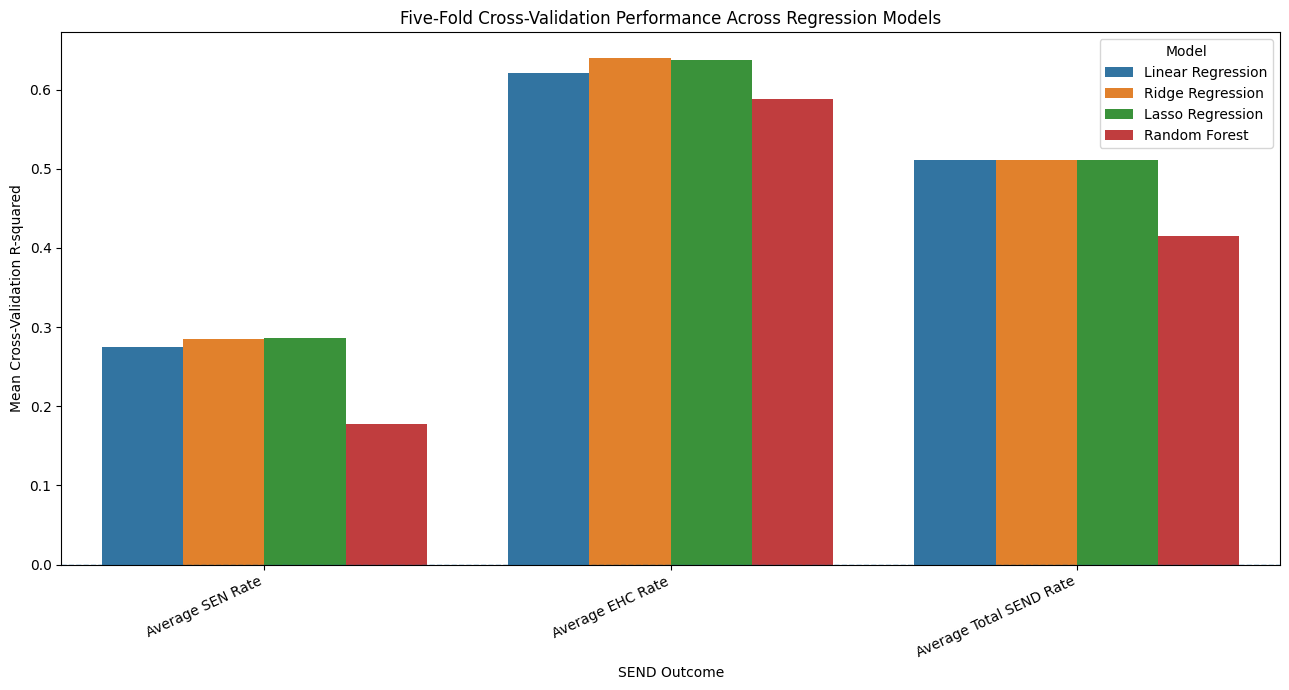

In [ ]:

#Compare the mean cross-validation R-squared of the four models
#across all SEND outcomes.
#
#This chart shows whether regularisation or non-linear modelling
#meaningfully improves on standard Linear Regression.


plt.figure(
    figsize=(13, 7)
)

sns.barplot(
    data=cross_validation_table,
    x="Outcome",
    y="Mean CV R-squared",
    hue="Model"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Five-Fold Cross-Validation Performance Across Regression Models"
)

plt.xlabel("SEND Outcome")
plt.ylabel("Mean Cross-Validation R-squared")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

## SECTION 3.30- PLOT ACTUAL VERSUS PREDICTED VALUES


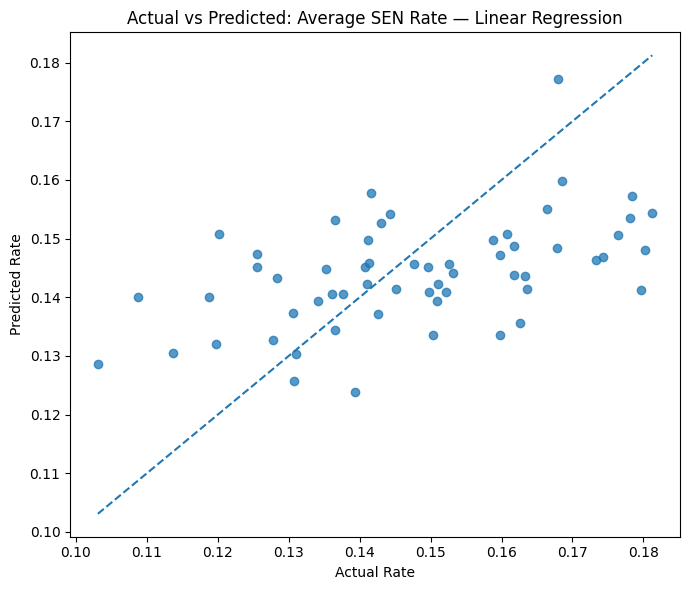

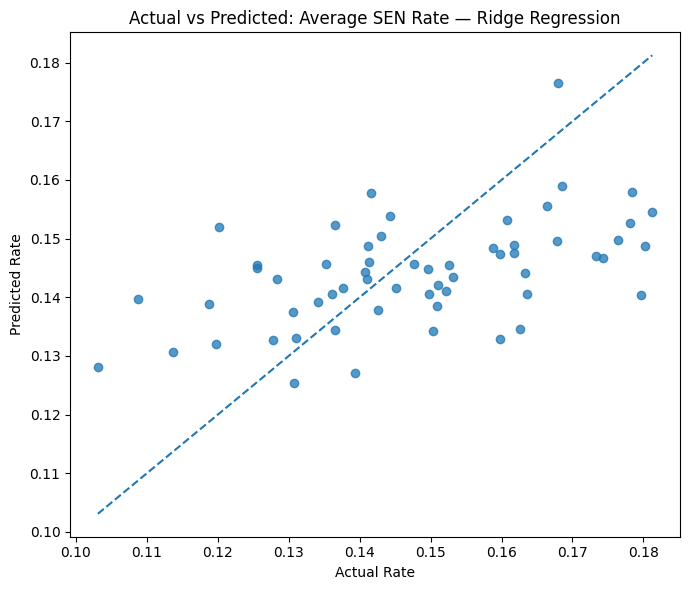

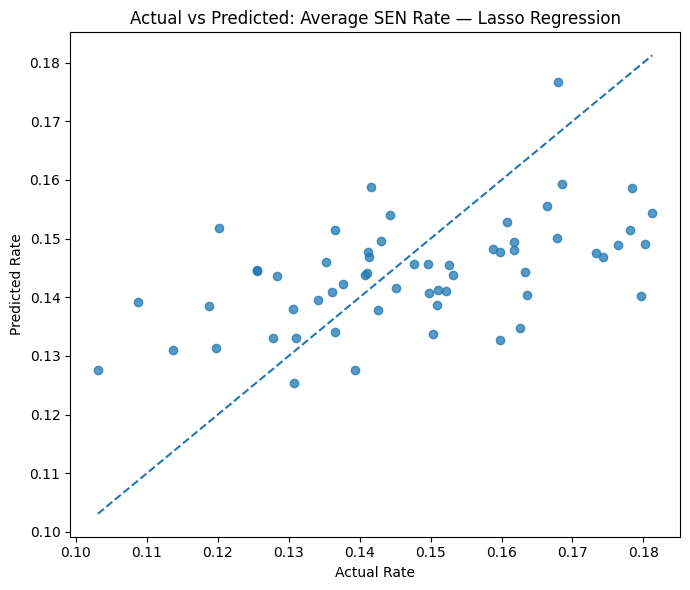

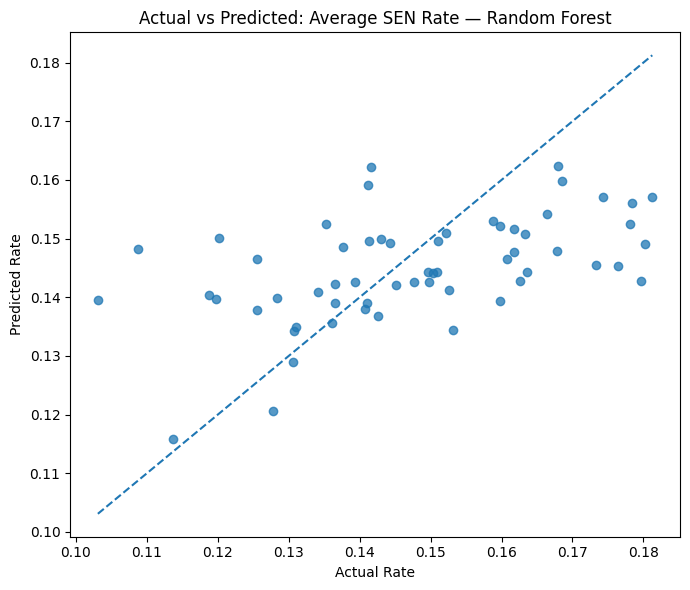

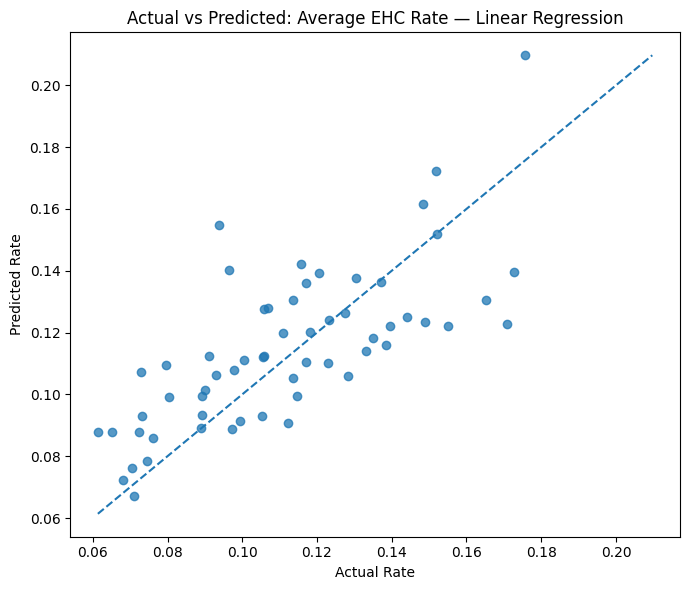

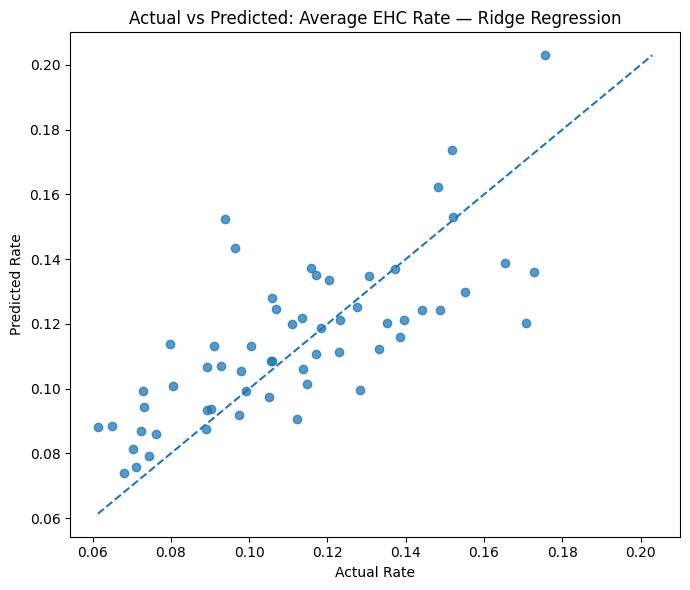

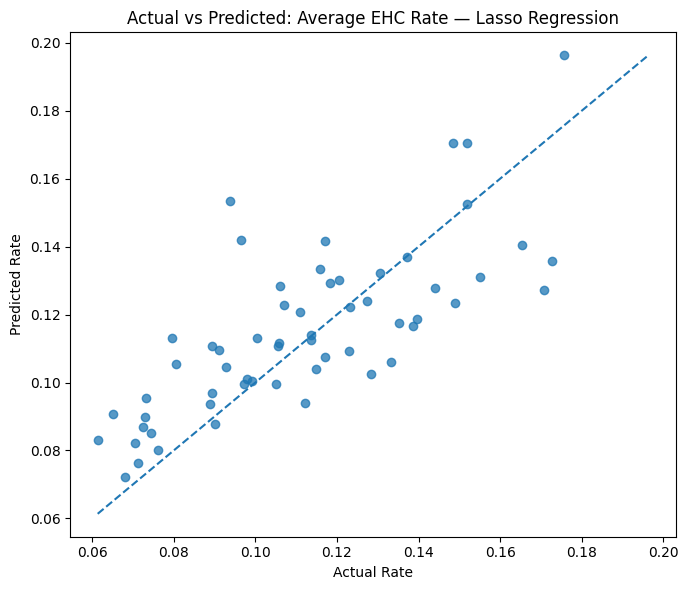

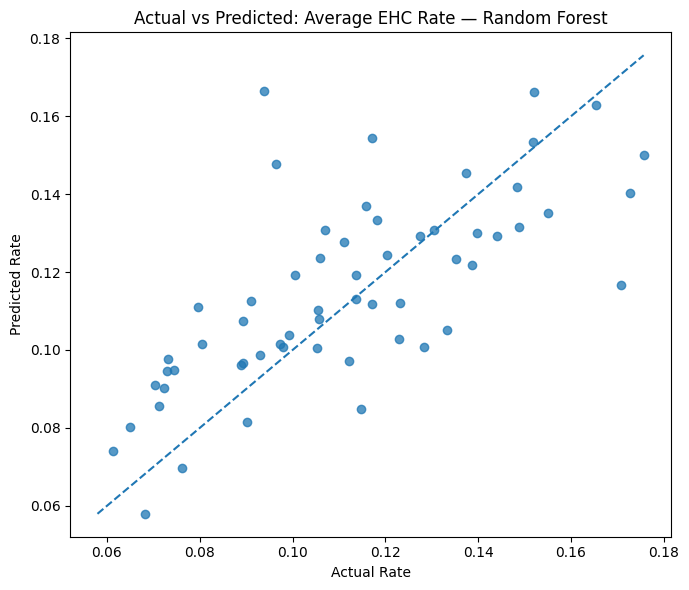

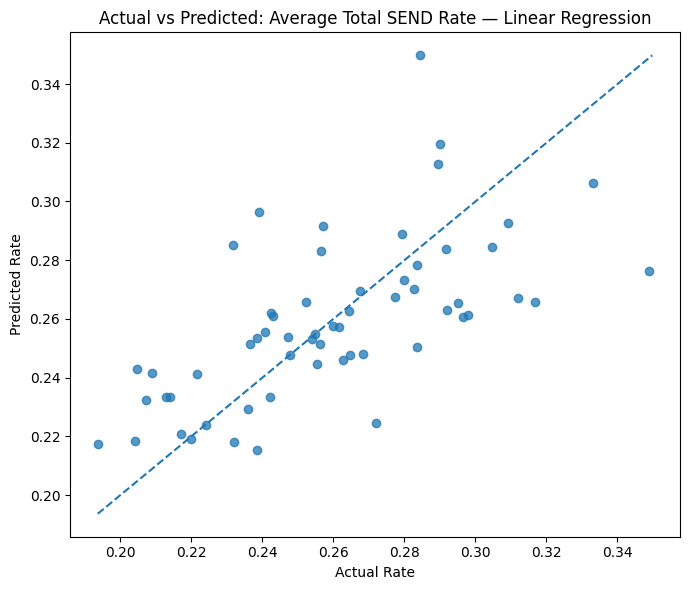

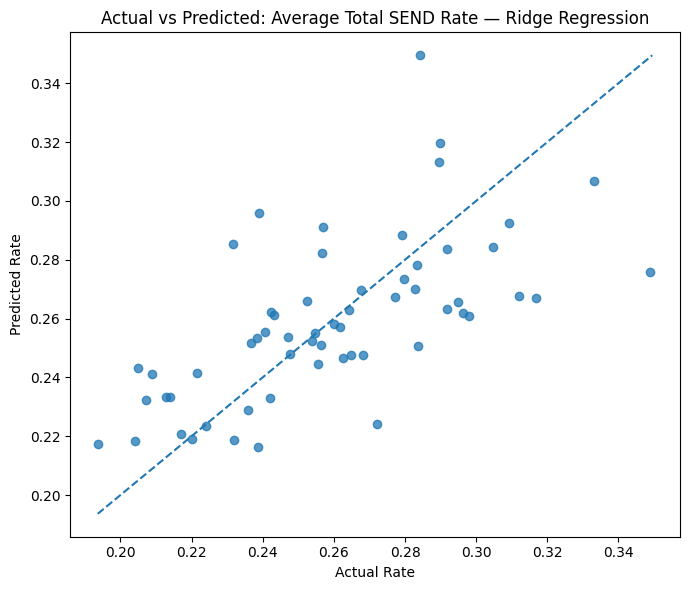

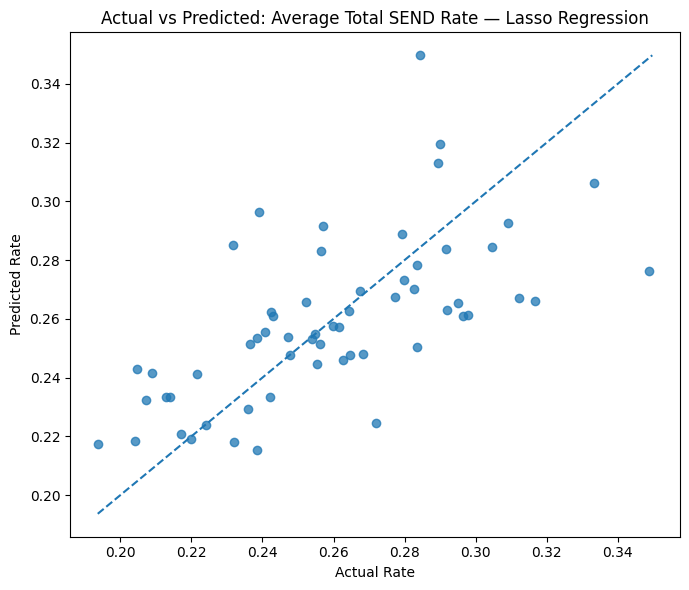

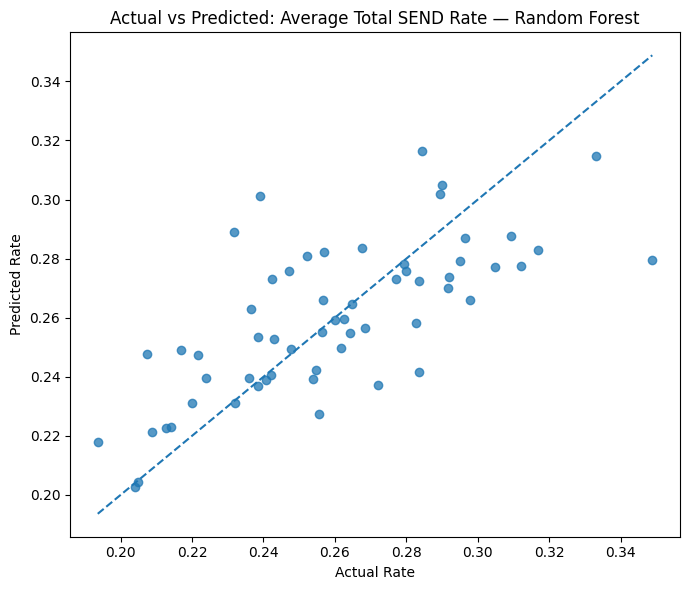

In [ ]:

#Compare observed SEND rates with test-set predictions.
#
#Points close to the diagonal reference line indicate accurate
#predictions.
#
#A wide scatter around the line indicates substantial unexplained
#variation.


for outcome in LA_REGRESSION_OUTCOMES:

    split = train_test_splits[outcome]

    for model_name, fitted_model in (
        fitted_ml_models[outcome].items()
    ):

        predictions = fitted_model.predict(
            split["X_test"]
        )

        plt.figure(
            figsize=(7, 6)
        )

        plt.scatter(
            split["y_test"],
            predictions,
            alpha=0.75
        )

        minimum_value = min(
            split["y_test"].min(),
            predictions.min()
        )

        maximum_value = max(
            split["y_test"].max(),
            predictions.max()
        )

        plt.plot(
            [
                minimum_value,
                maximum_value
            ],
            [
                minimum_value,
                maximum_value
            ],
            linestyle="--"
        )

        plt.title(
            f"Actual vs Predicted: "
            f"{outcome}- {model_name}"
        )

        plt.xlabel("Actual Rate")
        plt.ylabel("Predicted Rate")
        plt.tight_layout()
        plt.show()

## SECTION 3.31- EXTRACT TRANSFORMED FEATURE NAMES


In [ ]:

#Retrieve the predictor names after:
#numerical scaling;
#regional dummy encoding;
#Urbanity dummy encoding.

#This allows Ridge and Lasso coefficients to be matched back to
#understandable predictor names.


def get_pipeline_feature_names(
    fitted_pipeline
):
    """
    Return transformed predictor names from a fitted pipeline.
    """

    fitted_preprocessor = (
        fitted_pipeline.named_steps[
            "preprocessor"
        ]
    )

    feature_names = (
        fitted_preprocessor
        .get_feature_names_out()
        .tolist()
    )

    cleaned_feature_names = [
        feature_name
        .replace("numeric__", "")
        .replace("categorical__", "")

        for feature_name
        in feature_names
    ]

    return cleaned_feature_names

## SECTION 3.32- EXTRACT RIDGE REGRESSION COEFFICIENTS


In [ ]:

#Identify the direction and relative magnitude of standardised
#Ridge coefficients.
#
#Because numerical predictors are standardised, coefficient
#magnitudes are more comparable than unscaled OLS coefficients.
#
#Ridge does not normally reduce coefficients exactly to zero.


ridge_coefficient_tables = {}

for outcome in LA_REGRESSION_OUTCOMES:

    fitted_ridge = (
        fitted_ml_models[outcome][
            "Ridge Regression"
        ]
    )

    feature_names = (
        get_pipeline_feature_names(
            fitted_ridge
        )
    )

    coefficients = (
        fitted_ridge.named_steps[
            "model"
        ].coef_
    )

    ridge_table = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    ridge_table[
        "Absolute Coefficient"
    ] = (
        ridge_table["Coefficient"].abs()
    )

    ridge_table = ridge_table.sort_values(
        "Absolute Coefficient",
        ascending=False
    )

    ridge_coefficient_tables[outcome] = (
        ridge_table
    )

    print("=" * 85)
    print(f"RIDGE COEFFICIENTS: {outcome}")
    print("=" * 85)

    display(
        ridge_table.head(20).round(5)
    )

RIDGE COEFFICIENTS: Average SEN Rate


,Feature,Coefficient,Absolute Coefficient
17,geo-Political Zone_South West,0.0157,0.0157
16,geo-Political Zone_South East,0.0136,0.0136
2,Average Employment Score,0.0097,0.0097
18,geo-Political Zone_West Midlands,0.0096,0.0096
6,"Schools per 10,000 Pupils",0.0079,0.0079
12,geo-Political Zone_East of England,0.0078,0.0078
11,Urbanity Category_Most Urban,0.0077,0.0077
0,Average IMD Score,-0.0072,0.0072
14,geo-Political Zone_North East,0.0066,0.0066
13,geo-Political Zone_London,0.0066,0.0066


RIDGE COEFFICIENTS: Average EHC Rate


,Feature,Coefficient,Absolute Coefficient
7,"Special Schools per 10,000 Pupils",0.0285,0.0285
6,"Schools per 10,000 Pupils",-0.0107,0.0107
2,Average Employment Score,0.0083,0.0083
16,geo-Political Zone_South East,0.0079,0.0079
13,geo-Political Zone_London,0.0076,0.0076
4,Average Income Deprivation Affecting Children ...,-0.0067,0.0067
9,Urbanity Category_Moderately Urban,0.0052,0.0052
11,Urbanity Category_Most Urban,0.0047,0.0047
15,geo-Political Zone_North West,0.0036,0.0036
14,geo-Political Zone_North East,0.0029,0.0029


RIDGE COEFFICIENTS: Average Total SEND Rate


,Feature,Coefficient,Absolute Coefficient
13,geo-Political Zone_London,0.0351,0.0351
16,geo-Political Zone_South East,0.0332,0.0332
2,Average Employment Score,0.0263,0.0263
7,"Special Schools per 10,000 Pupils",0.0246,0.0246
0,Average IMD Score,-0.0231,0.0231
17,geo-Political Zone_South West,0.0219,0.0219
1,Average Income Score Rate,0.0203,0.0203
18,geo-Political Zone_West Midlands,0.0197,0.0197
4,Average Income Deprivation Affecting Children ...,-0.0195,0.0195
14,geo-Political Zone_North East,0.0179,0.0179


## SECTION 3.33- EXTRACT LASSO COEFFICIENTS


In [ ]:

#Identify which predictors Lasso retains and which it reduces to
#zero.

#Non-zero coefficients indicate predictors retained by the
#regularised model.

#A zero coefficient does not prove that a predictor is irrelevant.
#It means it adds limited predictive value once the other
#predictors and the selected penalty are considered.


lasso_coefficient_tables = {}

for outcome in LA_REGRESSION_OUTCOMES:

    fitted_lasso = (
        fitted_ml_models[outcome][
            "Lasso Regression"
        ]
    )

    feature_names = (
        get_pipeline_feature_names(
            fitted_lasso
        )
    )

    coefficients = (
        fitted_lasso.named_steps[
            "model"
        ].coef_
    )

    lasso_table = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    lasso_table[
        "Retained by Lasso"
    ] = (
        lasso_table["Coefficient"]
        .abs() > 1e-10
    )

    lasso_table[
        "Absolute Coefficient"
    ] = (
        lasso_table["Coefficient"].abs()
    )

    lasso_table = lasso_table.sort_values(
        "Absolute Coefficient",
        ascending=False
    )

    lasso_coefficient_tables[outcome] = (
        lasso_table
    )

    print("=" * 85)
    print(f"LASSO COEFFICIENTS: {outcome}")
    print("=" * 85)

    display(
        lasso_table[
            lasso_table[
                "Retained by Lasso"
            ]
        ].round(6)
    )

    print(
        "Number of retained predictors:",
        lasso_table[
            "Retained by Lasso"
        ].sum()
    )

LASSO COEFFICIENTS: Average SEN Rate


,Feature,Coefficient,Retained by Lasso,Absolute Coefficient
17,geo-Political Zone_South West,0.0158,True,0.0158
16,geo-Political Zone_South East,0.0133,True,0.0133
18,geo-Political Zone_West Midlands,0.0097,True,0.0097
2,Average Employment Score,0.0093,True,0.0093
11,Urbanity Category_Most Urban,0.0082,True,0.0082
6,"Schools per 10,000 Pupils",0.0076,True,0.0076
12,geo-Political Zone_East of England,0.0075,True,0.0075
13,geo-Political Zone_London,0.0059,True,0.0059
14,geo-Political Zone_North East,0.0059,True,0.0059
7,"Special Schools per 10,000 Pupils",-0.0049,True,0.0049


Number of retained predictors: 17
LASSO COEFFICIENTS: Average EHC Rate


,Feature,Coefficient,Retained by Lasso,Absolute Coefficient
7,"Special Schools per 10,000 Pupils",0.0291,True,0.0291
6,"Schools per 10,000 Pupils",-0.0110,True,0.0110
16,geo-Political Zone_South East,0.0036,True,0.0036
2,Average Employment Score,0.0027,True,0.0027


Number of retained predictors: 4
LASSO COEFFICIENTS: Average Total SEND Rate


,Feature,Coefficient,Retained by Lasso,Absolute Coefficient
13,geo-Political Zone_London,0.0362,True,0.0362
16,geo-Political Zone_South East,0.0340,True,0.0340
2,Average Employment Score,0.0267,True,0.0267
0,Average IMD Score,-0.0247,True,0.0247
7,"Special Schools per 10,000 Pupils",0.0245,True,0.0245
17,geo-Political Zone_South West,0.0225,True,0.0225
1,Average Income Score Rate,0.0223,True,0.0223
4,Average Income Deprivation Affecting Children ...,-0.0205,True,0.0205
18,geo-Political Zone_West Midlands,0.0202,True,0.0202
14,geo-Political Zone_North East,0.0185,True,0.0185


Number of retained predictors: 20


## SECTION 3.34- CALCULATE RANDOM FOREST PERMUTATION IMPORTANCE


In [ ]:

#Measure how much model performance declines when each original
#predictor is randomly rearranged.

#A larger importance value indicates that the predictor contributes
#more strongly to the Random Forest predictions.

#Permutation importance is calculated on the test dataset to
#reduce bias towards variables used heavily during training.


random_forest_importance_tables = {}

for outcome in LA_REGRESSION_OUTCOMES:

    split = train_test_splits[outcome]

    fitted_random_forest = (
        fitted_ml_models[outcome][
            "Random Forest"
        ]
    )

    importance_result = permutation_importance(
        estimator=fitted_random_forest,
        X=split["X_test"],
        y=split["y_test"],
        scoring="r2",
        n_repeats=30,
        random_state=42,
        n_jobs=-1
    )

    importance_table = pd.DataFrame({
        "Predictor": split["X_test"].columns,
        "Mean Permutation Importance":
            importance_result.importances_mean,
        "Importance Standard Deviation":
            importance_result.importances_std
    })

    importance_table = (
        importance_table
        .sort_values(
            "Mean Permutation Importance",
            ascending=False
        )
    )

    random_forest_importance_tables[
        outcome
    ] = importance_table

    print("=" * 85)
    print(
        f"RANDOM FOREST IMPORTANCE: {outcome}"
    )
    print("=" * 85)

    display(
        importance_table.round(5)
    )

RANDOM FOREST IMPORTANCE: Average SEN Rate


,Predictor,Mean Permutation Importance,Importance Standard Deviation
2,Average Employment Score,0.0698,0.0379
6,"Schools per 10,000 Pupils",0.0562,0.0273
0,Average IMD Score,0.0561,0.0284
5,Child Population Percentage,0.0557,0.0257
3,"Average Education, Skills and Training Score",0.0545,0.0253
1,Average Income Score Rate,0.0101,0.0126
10,geo-Political Zone,0.0076,0.0183
4,Average Income Deprivation Affecting Children ...,0.0067,0.0192
7,"Special Schools per 10,000 Pupils",0.0008,0.0244
9,Urbanity Category,0.0003,0.0057


RANDOM FOREST IMPORTANCE: Average EHC Rate


,Predictor,Mean Permutation Importance,Importance Standard Deviation
7,"Special Schools per 10,000 Pupils",1.7284,0.3066
6,"Schools per 10,000 Pupils",0.2303,0.0724
9,Urbanity Category,0.0165,0.0119
5,Child Population Percentage,0.0111,0.0113
4,Average Income Deprivation Affecting Children ...,0.0107,0.0081
3,"Average Education, Skills and Training Score",0.0042,0.0047
8,Pupils as Percentage of Population,0.0031,0.0066
1,Average Income Score Rate,0.0011,0.0040
10,geo-Political Zone,-0.0011,0.0045
0,Average IMD Score,-0.0031,0.0024


RANDOM FOREST IMPORTANCE: Average Total SEND Rate


,Predictor,Mean Permutation Importance,Importance Standard Deviation
7,"Special Schools per 10,000 Pupils",1.1153,0.1917
6,"Schools per 10,000 Pupils",0.1032,0.0361
1,Average Income Score Rate,0.0349,0.0113
3,"Average Education, Skills and Training Score",0.0174,0.0111
8,Pupils as Percentage of Population,0.0151,0.0080
0,Average IMD Score,0.0134,0.0123
4,Average Income Deprivation Affecting Children ...,0.0118,0.0075
9,Urbanity Category,0.0092,0.0098
5,Child Population Percentage,0.0027,0.0099
2,Average Employment Score,0.0000,0.0118


## SECTION 3.35- PLOT RANDOM FOREST PERMUTATION IMPORTANCE


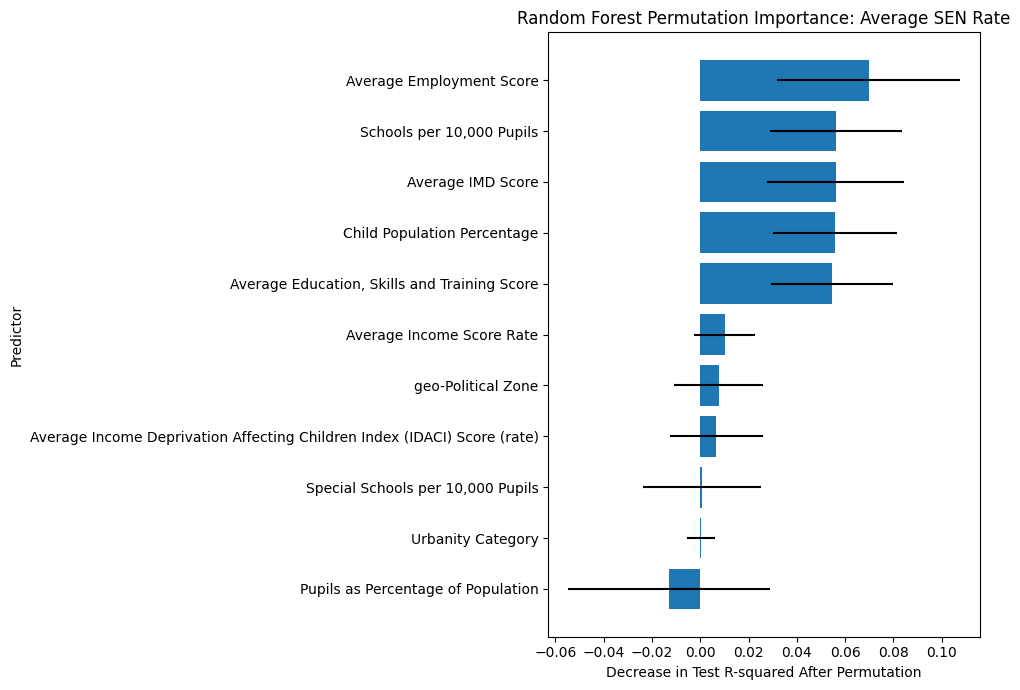

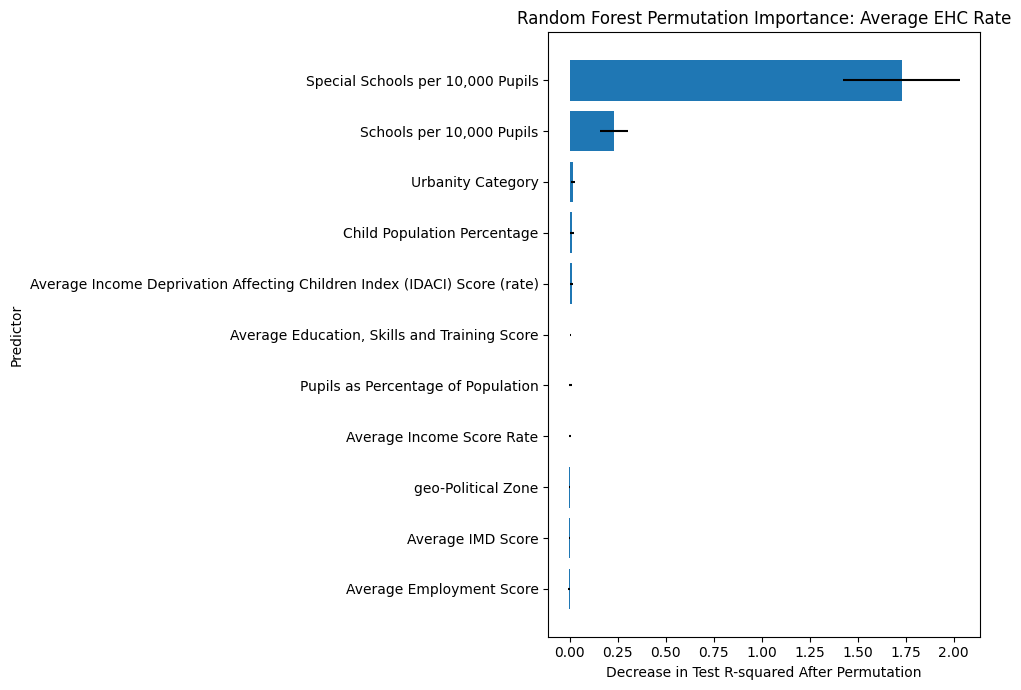

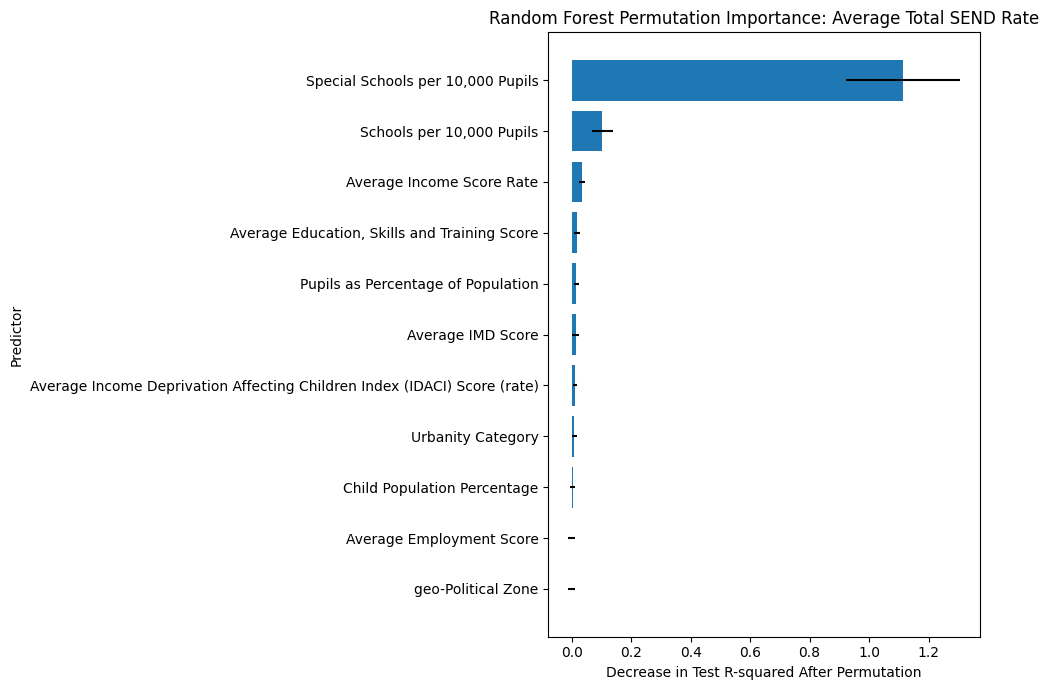

In [ ]:

#Visualise the predictors that contribute most strongly to the
#Random Forest predictions.
#
#Negative or near-zero importance suggests that rearranging the
#predictor does not reduce test performance.


for outcome, importance_table in (
    random_forest_importance_tables.items()
):

    plot_table = (
        importance_table
        .head(12)
        .sort_values(
            "Mean Permutation Importance",
            ascending=True
        )
    )

    plt.figure(
        figsize=(10, 7)
    )

    plt.barh(
        plot_table["Predictor"],
        plot_table[
            "Mean Permutation Importance"
        ],
        xerr=plot_table[
            "Importance Standard Deviation"
        ]
    )

    plt.title(
        f"Random Forest Permutation Importance: {outcome}"
    )

    plt.xlabel(
        "Decrease in Test R-squared After Permutation"
    )

    plt.ylabel("Predictor")
    plt.tight_layout()
    plt.show()

## SECTION 3.36- COMPARE URBANITY ACROSS MODELLING METHODS


In [ ]:

#Determine whether Urbanity is consistently identified as useful
#across:
#OLS;
#Ridge;
#Lasso;
#Random Forest.
#
#OLS provides statistical significance.
#Ridge provides stabilised coefficients.
#Lasso shows whether Urbanity is retained.
#Random Forest shows predictive importance.


urbanity_method_comparison_rows = []

for outcome in LA_REGRESSION_OUTCOMES:

    ols_urbanity = (
        urbanity_coefficient_tables[outcome]
    )

    ridge_urbanity = (
        ridge_coefficient_tables[outcome][
            ridge_coefficient_tables[outcome][
                "Feature"
            ].str.contains(
                "Urbanity Category",
                case=False,
                regex=False
            )
        ]
    )

    lasso_urbanity = (
        lasso_coefficient_tables[outcome][
            lasso_coefficient_tables[outcome][
                "Feature"
            ].str.contains(
                "Urbanity Category",
                case=False,
                regex=False
            )
        ]
    )

    rf_urbanity = (
        random_forest_importance_tables[
            outcome
        ][
            random_forest_importance_tables[
                outcome
            ]["Predictor"]
            == "Urbanity Category"
        ]
    )

    urbanity_method_comparison_rows.append({
        "Outcome": outcome,
        "OLS Joint Urbanity p-value":
            urbanity_joint_test_table.loc[
                urbanity_joint_test_table[
                    "Outcome"
                ] == outcome,
                "p-value"
            ].iloc[0],

        "Number of Significant OLS Urbanity Coefficients":
            int(
                ols_urbanity[
                    "Statistically Significant"
                ].sum()
            ),

        "Largest Absolute Ridge Urbanity Coefficient":
            (
                ridge_urbanity[
                    "Absolute Coefficient"
                ].max()
                if len(ridge_urbanity) > 0
                else np.nan
            ),

        "Number of Urbanity Terms Retained by Lasso":
            (
                int(
                    lasso_urbanity[
                        "Retained by Lasso"
                    ].sum()
                )
                if len(lasso_urbanity) > 0
                else 0
            ),

        "Random Forest Urbanity Importance":
            (
                rf_urbanity[
                    "Mean Permutation Importance"
                ].iloc[0]
                if len(rf_urbanity) > 0
                else np.nan
            )
    })

urbanity_method_comparison_table = (
    pd.DataFrame(
        urbanity_method_comparison_rows
    )
)

display(
    urbanity_method_comparison_table.round(5)
)

,Outcome,OLS Joint Urbanity p-value,Number of Significant OLS Urbanity Coefficients,Largest Absolute Ridge Urbanity Coefficient,Number of Urbanity Terms Retained by Lasso,Random Forest Urbanity Importance
0,Average SEN Rate,0.0672,2,0.0077,3,0.0003
1,Average EHC Rate,0.4233,0,0.0052,0,0.0165
2,Average Total SEND Rate,0.2275,1,0.0124,3,0.0092


## SECTION 3.37-  URBANITY RESEARCH-QUESTION CONCLUSION


In [ ]:

#Generate a cautious conclusion for:
#
#"Do urban and rural Local Authorities differ significantly in
#SEND support levels?"
#
#The conclusion is based primarily on:
#the joint Urbanity test in the SEN Support OLS model;
#individual Urbanity coefficients;
#whether regularised models retain Urbanity;
#Random Forest predictive importance.




SEN_OUTCOME_NAME = "Average SEN Rate"

sen_joint_row = urbanity_joint_test_table[
    urbanity_joint_test_table[
        "Outcome"
    ] == SEN_OUTCOME_NAME
].iloc[0]

sen_urbanity_coefficients = (
    urbanity_coefficient_tables[
        SEN_OUTCOME_NAME
    ]
)

number_significant_categories = int(
    sen_urbanity_coefficients[
        "Statistically Significant"
    ].sum()
)

if sen_joint_row["p-value"] < 0.05:

    urbanity_overall_conclusion = (
        "Urbanity was jointly statistically significant in the "
        "extended SEN Support OLS model.This indicates that at "
        "least one Urbanity category differed from the Most Urban "
        "reference group after controlling for deprivation, region, "
        "demographic characteristics and school provision."
    )

else:

    urbanity_overall_conclusion = (
        "Urbanity was not jointly statistically significant in the "
        "extended SEN Support OLS model.The analysis therefore did "
        "not find strong evidence that SEN Support rates differed "
        "systematically across the Urbanity categories after "
        "controlling for deprivation, region, demographic "
        "characteristics and school provision."
    )

print(urbanity_overall_conclusion)

print(
    "\nNumber of individually significant Urbanity categories:",
    number_significant_categories
)

print(
    "\nImportant interpretation: this result represents an adjusted "
    "association and does not establish that Urbanity causes changes "
    "in SEN Support rates."
)

Urbanity was not jointly statistically significant in the extended SEN Support OLS model. The analysis therefore did not find strong evidence that SEN Support rates differed systematically across the Urbanity categories after controlling for deprivation, region, demographic characteristics and school provision.

Number of individually significant Urbanity categories: 2

Important interpretation: this result represents an adjusted association and does not establish that Urbanity causes changes in SEN Support rates.


## SECTION 3.38- PRINT CONCISE MODEL PERFORMANCE SUMMARIES


In [ ]:

#Present the best-performing model for each outcome and compare it
#with OLS explanatory performance.


print("=" * 85)
print("SECTION 4: REGRESSION MODEL SUMMARY")
print("=" * 85)

for outcome in LA_REGRESSION_OUTCOMES:

    best_prediction_row = (
        preferred_models_table[
            preferred_models_table[
                "Outcome"
            ] == outcome
        ].iloc[0]
    )

    extended_ols_row = (
        ols_model_comparison_table[
            (
                ols_model_comparison_table[
                    "Outcome"
                ] == outcome
            )
            &
            (
                ols_model_comparison_table[
                    "Model"
                ] == "Extended OLS"
            )
        ].iloc[0]
    )

    print("\n" + "-" * 85)
    print(outcome)

    print(
        "Extended OLS R-squared:",
        round(
            extended_ols_row["R-squared"],
            4
        )
    )

    print(
        "Extended OLS adjusted R-squared:",
        round(
            extended_ols_row[
                "Adjusted R-squared"
            ],
            4
        )
    )

    print(
        "Preferred predictive model:",
        best_prediction_row["Model"]
    )

    print(
        "Preferred model test R-squared:",
        round(
            best_prediction_row[
                "Test R-squared"
            ],
            4
        )
    )

    print(
        "Preferred model mean CV R-squared:",
        round(
            best_prediction_row[
                "Mean CV R-squared"
            ],
            4
        )
    )

    print(
        "Preferred model test RMSE:",
        round(
            best_prediction_row[
                "Test RMSE"
            ],
            4
        )
    )

    print(
        "Preferred model test MAE:",
        round(
            best_prediction_row[
                "Test MAE"
            ],
            4
        )
    )

SECTION 4: REGRESSION MODEL SUMMARY

-------------------------------------------------------------------------------------
Average SEN Rate
Extended OLS R-squared: 0.3694
Extended OLS adjusted R-squared: 0.3232
Preferred predictive model: Lasso Regression
Preferred model test R-squared: 0.2278
Preferred model mean CV R-squared: 0.286
Preferred model test RMSE: 0.0168
Preferred model test MAE: 0.0141

-------------------------------------------------------------------------------------
Average EHC Rate
Extended OLS R-squared: 0.6959
Extended OLS adjusted R-squared: 0.6737
Preferred predictive model: Ridge Regression
Preferred model test R-squared: 0.5232
Preferred model mean CV R-squared: 0.6403
Preferred model test RMSE: 0.0203
Preferred model test MAE: 0.016

-------------------------------------------------------------------------------------
Average Total SEND Rate
Extended OLS R-squared: 0.5834
Extended OLS adjusted R-squared: 0.5529
Preferred predictive model: Ridge Regression
Pre

## SECTION 3.39- CREATE THE REGRESSION-OUTPUT FOLDER


In [ ]:

#Store regression results, coefficient tables, model comparisons,
#Urbanity findings and predictor-importance outputs.


REGRESSION_OUTPUT_FOLDER = (
    "/content/drive/MyDrive/MSC Dissertation/"
    "Final Main 3/Analysis Outputs/"
    "Regression Modelling"
)

os.makedirs(
    REGRESSION_OUTPUT_FOLDER,
    exist_ok=True
)

REGRESSION_RESULTS_PATH = os.path.join(
    REGRESSION_OUTPUT_FOLDER,
    "LA_Regression_Modelling_Results.xlsx"
)

print("Regression-output folder:")
print(REGRESSION_OUTPUT_FOLDER)

Regression-output folder:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/Regression Modelling


## SECTION 3.40- EXPORT REGRESSION RESULTS TO EXCEL


In [ ]:

#Save the explanatory, predictive and Urbanity results


with pd.ExcelWriter(
    REGRESSION_RESULTS_PATH,
    engine="openpyxl"
) as writer:

    ols_model_comparison_table.to_excel(
        writer,
        sheet_name="OLS Model Comparison",
        index=False
    )

    ridge_tuning_table.to_excel(
        writer,
        sheet_name="Ridge Tuning",
        index=False
    )

    lasso_tuning_table.to_excel(
        writer,
        sheet_name="Lasso Tuning",
        index=False
    )

    random_forest_tuning_table.to_excel(
        writer,
        sheet_name="RF Tuning",
        index=False
    )

    final_model_comparison_table.to_excel(
        writer,
        sheet_name="Final Model Comparison",
        index=False
    )

    preferred_models_table.to_excel(
        writer,
        sheet_name="Preferred Models",
        index=False
    )

    urbanity_joint_test_table.to_excel(
        writer,
        sheet_name="Urbanity Joint Tests",
        index=False
    )

    urbanity_method_comparison_table.to_excel(
        writer,
        sheet_name="Urbanity Model Comparison",
        index=False
    )

    for outcome in LA_REGRESSION_OUTCOMES:

        short_outcome = (
            outcome
            .replace(
                "Average ",
                ""
            )
            .replace(
                " Rate",
                ""
            )
            .replace(
                "Total SEND",
                "Total"
            )
        )

        core_ols_coefficient_tables[
            outcome
        ].to_excel(
            writer,
            sheet_name=(
                f"Core OLS {short_outcome}"
            )[:31],
            index=False
        )

        extended_ols_coefficient_tables[
            outcome
        ].to_excel(
            writer,
            sheet_name=(
                f"Extended OLS {short_outcome}"
            )[:31],
            index=False
        )

        urbanity_coefficient_tables[
            outcome
        ].to_excel(
            writer,
            sheet_name=(
                f"Urbanity {short_outcome}"
            )[:31],
            index=False
        )

        ridge_coefficient_tables[
            outcome
        ].to_excel(
            writer,
            sheet_name=(
                f"Ridge {short_outcome}"
            )[:31],
            index=False
        )

        lasso_coefficient_tables[
            outcome
        ].to_excel(
            writer,
            sheet_name=(
                f"Lasso {short_outcome}"
            )[:31],
            index=False
        )

        random_forest_importance_tables[
            outcome
        ].to_excel(
            writer,
            sheet_name=(
                f"RF Importance {short_outcome}"
            )[:31],
            index=False
        )

print("Regression results saved successfully:")
print(REGRESSION_RESULTS_PATH)

Regression results saved successfully:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/Regression Modelling/LA_Regression_Modelling_Results.xlsx


## SECTION 3.41- SAVE TEST PREDICTIONS AND RESIDUALS


In [ ]:

#Create a reusable table containing:
#actual SEND outcomes;
#model predictions;
#prediction residuals.


prediction_output_tables = {}

for outcome in LA_REGRESSION_OUTCOMES:

    split = train_test_splits[outcome]

    outcome_prediction_table = (
        la_regression.loc[
            split["X_test"].index,
            [
                "LA Authority",
                "LAD24CD",
                outcome
            ]
        ]
        .copy()
    )

    outcome_prediction_table.rename(
        columns={
            outcome: "Actual Outcome"
        },
        inplace=True
    )

    for model_name, fitted_model in (
        fitted_ml_models[outcome].items()
    ):

        predictions = fitted_model.predict(
            split["X_test"]
        )

        safe_model_name = (
            model_name
            .replace(" ", "_")
        )

        outcome_prediction_table[
            f"{safe_model_name}_Prediction"
        ] = predictions

        outcome_prediction_table[
            f"{safe_model_name}_Residual"
        ] = (
            outcome_prediction_table[
                "Actual Outcome"
            ]
            -
            predictions
        )

    prediction_output_tables[
        outcome
    ] = outcome_prediction_table

    short_outcome = (
        outcome
        .replace(
            "Average ",
            ""
        )
        .replace(
            " Rate",
            ""
        )
        .replace(
            "Total SEND",
            "Total"
        )
        .replace(
            " ",
            "_"
        )
    )

    prediction_path = os.path.join(
        REGRESSION_OUTPUT_FOLDER,
        f"{short_outcome}_Test_Predictions.xlsx"
    )

    outcome_prediction_table.to_excel(
        prediction_path,
        index=False
    )

    print(
        f"Saved predictions for {outcome}:",
        prediction_path
    )

Saved predictions for Average SEN Rate: /content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/Regression Modelling/SEN_Test_Predictions.xlsx
Saved predictions for Average EHC Rate: /content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/Regression Modelling/EHC_Test_Predictions.xlsx
Saved predictions for Average Total SEND Rate: /content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/Regression Modelling/Total_Test_Predictions.xlsx
